# **RQ1**

For each node in every snapshot, compute the node's degree and record it in a CSV file.

In [1]:
import pandas as pd
import igraph as ig
from pathlib import Path
import time

graph_dir = Path("networks_hybrid")        
output_dir = Path("degree_csv_igraph_snapshot")
output_dir.mkdir(exist_ok=True)



print("[START] Estrazione degree dai grafi igraph")

for snap in range(1, 8):
    t0 = time.time()

    graph_file = graph_dir / f"graph_snap{snap}_hybrid.igp"
    output_csv = output_dir / f"node_degree_snap{snap}_hybrid.csv"

    print(f"\n[SNAPSHOT {snap}]")

    # importo g
    g = ig.Graph.Read_Pickle(graph_file)

   
    degrees = g.degree()   # numero di vicini

   
    tokens = g.vs["token"]

    df_out = pd.DataFrame({
        "token": tokens,
        "degree": degrees
    })

    df_out.to_csv(output_csv, index=False)

    print(
        f"[DONE] nodi={g.vcount()}, archi={g.ecount()} "
        f"in {time.time() - t0:.2f}s"
    )

print("\n[TOTAL] Tutti i CSV generati")


[START] Estrazione degree dai grafi igraph

[SNAPSHOT 1]
[DONE] nodi=34742, archi=3033079 in 2.93s

[SNAPSHOT 2]
[DONE] nodi=28017, archi=1985640 in 1.77s

[SNAPSHOT 3]
[DONE] nodi=28028, archi=1930980 in 1.60s

[SNAPSHOT 4]
[DONE] nodi=34431, archi=3011365 in 2.85s

[SNAPSHOT 5]
[DONE] nodi=37089, archi=3482725 in 3.42s

[SNAPSHOT 6]
[DONE] nodi=37658, archi=3604324 in 3.26s

[SNAPSHOT 7]
[DONE] nodi=31000, archi=2390413 in 2.40s

[TOTAL] Tutti i CSV generati


# Individual shrinkage Si
Compute the individual shrinkage for each node at each time step.
Use the first snapshot in which the word appears as the baseline (t0).

In [3]:
import pandas as pd
from pathlib import Path
import numpy as np

degree_dir = Path("degree_csv_igraph_snapshot")
output_csv = Path("shrinkage_i_norm.csv")

snapshots = range(1, 8)

# --- leggo tutti i degree ---
all_degrees = {}  # all_degrees[snap][token] = degree
for snap in snapshots:
    df = pd.read_csv(degree_dir / f"node_degree_snap{snap}_hybrid.csv")
    
    df = df.dropna(subset=["token"])
    df["token"] = df["token"].astype(str)
    
    all_degrees[snap] = dict(zip(df["token"], df["degree"]))

# --- trovo primo snapshot per ogni token ---
first_snap = {}
appear_count = {}  # Conteggio snapshot di comparsa
for snap in snapshots:
    for token in all_degrees[snap]:
        if token not in first_snap:
            first_snap[token] = snap
            appear_count[token] = 1
        else:
            appear_count[token] += 1

# --- filtro token che appaiono in almeno 5 snapshot ---
tokens = [tok for tok, count in appear_count.items() if count >= 5]

# --- calcolo media grado per snapshot ---
network_stats = {} 
for snap in snapshots: 
    degrees_snap = all_degrees[snap] 
    mean_deg = np.mean(list(degrees_snap.values())) if degrees_snap else 1 
    network_stats[snap] = mean_deg 

# --- calcolo Shrinkage con baseline temporale t-1 ---
shrinkage_data = {"token": tokens}

for snap in snapshots:
    shrinkage_data[f"shrinkage_snap{snap}"] = []

for token in tokens:
    for snap in snapshots:
        if snap == snapshots[0]:
            s = np.nan
        else:
            prev_snap = snap - 1
            
            degree_raw_t = all_degrees[snap].get(token, 0)
            degree_raw_prev = all_degrees[prev_snap].get(token, 0)
            
            norm_degree_t = degree_raw_t / network_stats[snap]
            norm_degree_prev = degree_raw_prev / network_stats[prev_snap]
            
            if norm_degree_prev == 0:
                # Penalizzazione per assenza precedente
                s = 1 if norm_degree_t != 0 else np.nan
            else:
                s = 1 - (norm_degree_t / norm_degree_prev)
        
        shrinkage_data[f"shrinkage_snap{snap}"].append(s)

# --- salvo CSV finale ---
df_shrink_filtered = pd.DataFrame(shrinkage_data)
df_shrink_filtered.to_csv(output_csv, index=False)

print(f"[DONE] Shrinkage calcolato per token in ≥5 snapshot in {output_csv}")


[DONE] Shrinkage calcolato per token in ≥5 snapshot in shrinkage_i_norm.csv


In [4]:
len(df_shrink_filtered)

27144

# cc

In [47]:
import pandas as pd
import numpy as np
import igraph as ig
from pathlib import Path

# =============================================================================
# CONFIGURAZIONE
# =============================================================================

# Cartella dove sono salvati i file dei grafi (es. .gml, .graphml, .pickle)
input_graphs_dir = Path("networks_hybrid_annotated") 

# Cartella output finale
output_csv = Path("semantic_shrinkage_clustering.csv")

# Range degli snapshot
snapshots = range(1, 8)

# =============================================================================
# 1. CARICAMENTO GRAFI E CALCOLO CLUSTERING
# =============================================================================
print("--- FASE 1: Caricamento Grafi e Calcolo CC ---")

all_clustering = {}      # {snap: {token: cc_value}}
network_cc_means = {}    # {snap: media_globale_cc}

for snap in snapshots:
    # ADATTA L'ESTENSIONE AL TUO FORMATO (.gml, .graphml, .pickle, etc.)
    # Se usi pickle: g = ig.Graph.Read_Pickle(graph_path)
    graph_path = input_graphs_dir / f"graph_snap{snap}_hybrid.igp"
    
    if not graph_path.exists():
        print(f"[SKIP] Grafo non trovato: {graph_path}")
        continue
        
    try:
        # Caricamento Grafo
        g = ig.Graph.Read_Pickle(graph_path) 
        
        # Opzionale: Se il grafo ha self-loops o multi-edges, semplifica per correttezza del CC
        # g = g.simplify() 
        
        # Calcolo Clustering Coefficient (Transitivity Local Undirected)
        # mode="zero": se il nodo ha grado < 2, il CC è 0 (invece di NaN)
        cc_values = g.transitivity_local_undirected(mode="zero")
        
        # Assumiamo che i nodi abbiano un attributo "name" o "label" con la parola
        # Se il tuo attributo si chiama diversamente (es. "id"), cambialo qui sotto
        node_names = g.vs["token"] 
        
        # Salviamo nel dizionario
        all_clustering[snap] = dict(zip(node_names, cc_values))
        
        # Calcolo Media Globale per Normalizzazione
        # Escludiamo eventuali nodi isolati se vuoi una media più "pura", 
        # ma matematicamente la media su tutti i nodi è corretta per lo shrinkage.
        mean_cc = np.mean(cc_values) if cc_values else 1
        network_cc_means[snap] = mean_cc
        
        print(f"Snap {snap}: Caricato (Nodi: {len(node_names)}, CC Medio: {mean_cc:.4f})")
        
    except Exception as e:
        print(f"Errore su Snap {snap}: {e}")

# =============================================================================
# 2. FILTRAGGIO TOKEN (Deve esistere in almeno N snapshot)
# =============================================================================
print("\n--- FASE 2: Filtraggio Token ---")

# Identifica il primo snapshot (t0)
first_snap = {}
for snap in snapshots:
    if snap in all_clustering:
        for token in all_clustering[snap]:
            if token not in first_snap:
                first_snap[token] = snap

# Conta apparizioni
appear_count = {token: 0 for token in first_snap}
for snap in snapshots:
    if snap in all_clustering:
        for token in first_snap:
            if token in all_clustering[snap]:
                appear_count[token] += 1

# Filtro (es. almeno 5 apparizioni)
min_appearances = 5
tokens = sorted([tok for tok, count in appear_count.items() if count >= min_appearances])
print(f"Token selezionati per l'analisi: {len(tokens)}")

# =============================================================================
# 3. CALCOLO SHRINKAGE NORMALIZZATO
# =============================================================================
print("\n--- FASE 3: Calcolo Shrinkage ---")

shrinkage_data = {"token": tokens}

for snap in snapshots:
    shrink_values = []
    
    # Media CC della rete corrente (Denominatore inflazione)
    mean_cc_current = network_cc_means.get(snap, 1)
    
    for token in tokens:
        t0 = first_snap[token]
        
        # Se lo snapshot è precedente alla nascita -> NaN
        if snap < t0:
            shrink_values.append(np.nan)
            continue
        
        # Dati Baseline (t0)
        mean_cc_t0 = network_cc_means.get(t0, 1)
        raw_cc_t0 = all_clustering[t0].get(token, 0)
        
        # Dati Correnti (t)
        raw_cc_t = all_clustering.get(snap, {}).get(token, 0)
        
        # Normalizzazione
        norm_cc_t0 = raw_cc_t0 / mean_cc_t0 if mean_cc_t0 > 0 else 0
        norm_cc_t  = raw_cc_t / mean_cc_current if mean_cc_current > 0 else 0
        
        # Calcolo Shrinkage S
        # Se norm_cc_t0 è 0, non possiamo calcolare la variazione percentuale.
        # Caso tipico: parola nata come "stella" (CC=0).
        if norm_cc_t0 == 0:
            s = np.nan 
        else:
            s = 1 - (norm_cc_t / norm_cc_t0)
            
        shrink_values.append(s)
    
    shrinkage_data[f"shrinkage_snap{snap}"] = shrink_values

# =============================================================================
# 4. SALVATAGGIO
# =============================================================================
df_final = pd.DataFrame(shrinkage_data)
df_final.to_csv(output_csv, index=False)
print(f"[DONE] File salvato in: {output_csv}")



--- FASE 1: Caricamento Grafi e Calcolo CC ---
Snap 1: Caricato (Nodi: 34742, CC Medio: 0.3262)
Snap 2: Caricato (Nodi: 28017, CC Medio: 0.3037)
Snap 3: Caricato (Nodi: 28028, CC Medio: 0.2943)
Snap 4: Caricato (Nodi: 34431, CC Medio: 0.2914)
Snap 5: Caricato (Nodi: 37089, CC Medio: 0.2895)
Snap 6: Caricato (Nodi: 37658, CC Medio: 0.2890)
Snap 7: Caricato (Nodi: 31000, CC Medio: 0.2853)

--- FASE 2: Filtraggio Token ---
Token selezionati per l'analisi: 27144

--- FASE 3: Calcolo Shrinkage ---
[DONE] File salvato in: semantic_shrinkage_clustering.csv


# S_aggr
Compute the aggregated shrinkage for each node.

In [5]:
import pandas as pd
from pathlib import Path
import numpy as np

# CSV shrinkage
shrink_csv = "shrinkage_i_norm.csv"
df_shrink = pd.read_csv(shrink_csv)

snapshots = range(1, 8)
freq_dir = Path("../embedding/frequencies_all")

# df delle frequenze per tutti gli snapshot
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(freq_file)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    # filtra solo token presenti nello shrinkage
    df_freq = df_freq[df_freq["token"].isin(df_shrink["token"])]

    freq_dfs.append(df_freq)

# Merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# allineamento finale
df_all = df_shrink.merge(df_freq_all, on="token", how="inner")

# inizializzazione vettoriale
numeratore = pd.Series(0.0, index=df_all.index)
denominatore = pd.Series(0.0, index=df_all.index)

for snap in snapshots:
    s_col = f"shrinkage_snap{snap}"
    w_col = f"freq_snap{snap}"

    numeratore += df_all[s_col].fillna(0) * df_all[w_col].fillna(0)
    denominatore += df_all[w_col].fillna(0)

# S_aggregato (evita divisione per zero)
df_all["S_aggregato"] = np.where(
    denominatore > 0,
    numeratore / denominatore,
    np.nan
)

df_result = df_all[["token", "S_aggregato"]]
df_result.to_csv("shrinkage_aggr_filtered_norm.csv", index=False)

print(df_result.head())


         token  S_aggregato
0    disputato    -0.061882
1     attutire     0.035465
2  coccodrillo    -1.813846
3  stravagante    -0.013866
4  indicazione    -0.031366


In [6]:
len(df_result)

27144

In [48]:
import pandas as pd
from pathlib import Path
import numpy as np

# CSV shrinkage
shrink_csv = "semantic_shrinkage_clustering.csv"
df_shrink = pd.read_csv(shrink_csv)

snapshots = range(1, 8)
freq_dir = Path("../embedding/frequencies_all")

# df delle frequenze per tutti gli snapshot
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(freq_file)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    # filtra solo token presenti nello shrinkage
    df_freq = df_freq[df_freq["token"].isin(df_shrink["token"])]

    freq_dfs.append(df_freq)

# Merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# allineamento finale
df_all = df_shrink.merge(df_freq_all, on="token", how="inner")

# inizializzazione vettoriale
numeratore = pd.Series(0.0, index=df_all.index)
denominatore = pd.Series(0.0, index=df_all.index)

for snap in snapshots:
    s_col = f"shrinkage_snap{snap}"
    w_col = f"freq_snap{snap}"

    numeratore += df_all[s_col].fillna(0) * df_all[w_col].fillna(0)
    denominatore += df_all[w_col].fillna(0)

# S_aggregato (evita divisione per zero)
df_all["S_aggregato"] = np.where(
    denominatore > 0,
    numeratore / denominatore,
    np.nan
)

df_result = df_all[["token", "S_aggregato"]]
df_result.to_csv("shrinkage_aggr_cc.csv", index=False)

print(df_result.head())


     token  S_aggregato
0      -l'    -0.480577
1     aalà    -0.867658
2    abaco    -0.488352
3  abanese     0.114195
4    abare    -0.922853


In [49]:
len(df_result)

27144

Describe S_aggr

In [8]:
import pandas as pd

df = pd.read_csv("shrinkage_aggr_filtered_norm.csv")

df["S_aggregato"].describe()


count    27144.000000
mean        -0.291433
std          0.926383
min        -44.786682
25%         -0.324917
50%         -0.134909
75%         -0.005688
max          0.883961
Name: S_aggregato, dtype: float64

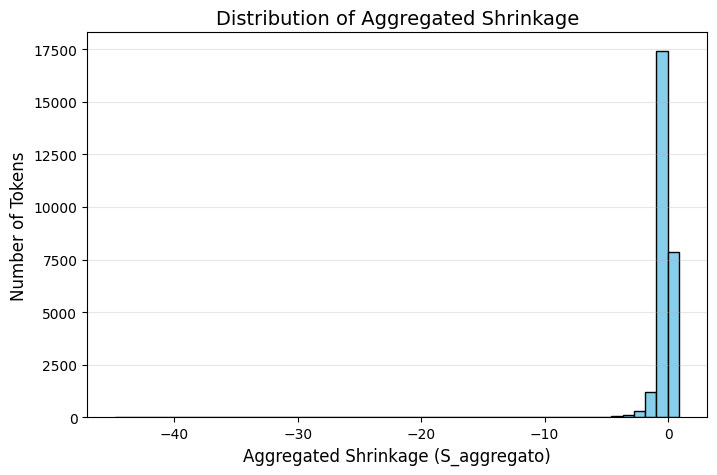

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["S_aggregato"].dropna(), bins=50, color="skyblue", edgecolor="black")
plt.xlabel("Aggregated Shrinkage (S_aggregato)", fontsize=12)
plt.ylabel("Number of Tokens", fontsize=12)
plt.title("Distribution of Aggregated Shrinkage", fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()


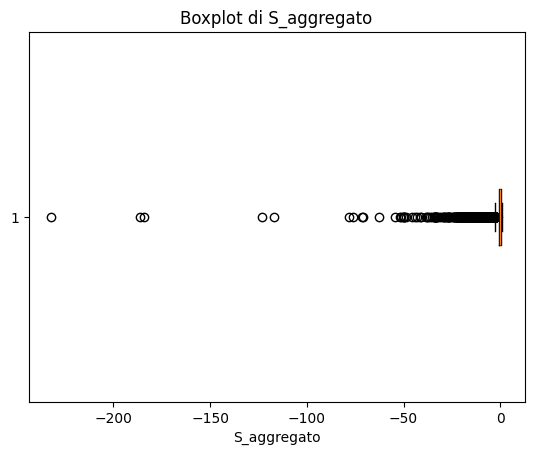

In [8]:
plt.figure()
plt.boxplot(df["S_aggregato"].dropna(), vert=False)
plt.xlabel("S_aggregato")
plt.title("Boxplot di S_aggregato")
plt.show()


In [10]:
df["class"] = "neutral"
df.loc[df["S_aggregato"] > 0, "class"] = "shrinkage"
df.loc[df["S_aggregato"] < 0, "class"] = "expansion"

df["class"].value_counts(normalize=True) * 100


class
expansion    75.983643
shrinkage    24.016357
Name: proportion, dtype: float64

In [11]:
# top parole con espansione forte
df.sort_values("S_aggregato", ascending=True).head(20)

,token,S_aggregato,class
14470,in',-44.786682,expansion
24734,plus,-42.853814,expansion
14665,lee,-40.262017,expansion
15405,umida,-27.650720,expansion
7611,canon,-27.286975,expansion
20331,triei,-25.428074,expansion
22504,varzo,-21.525209,expansion
22209,atala,-18.109423,expansion
10325,gibuto,-15.961322,expansion
23696,nilo,-15.954902,expansion


In [12]:
# top parole con shrinkage forte
df.sort_values("S_aggregato", ascending=False).head(20)

,token,S_aggregato,class
11251,peci,0.883961,shrinkage
21413,cernere,0.767380,shrinkage
5751,il',0.732135,shrinkage
24388,piffero,0.722819,shrinkage
16458,loreo,0.712157,shrinkage
24222,bura,0.710876,shrinkage
19015,piperno,0.707823,shrinkage
726,malvina,0.701340,shrinkage
7859,deu,0.692516,shrinkage
8249,ma',0.685006,shrinkage


# RQ1
Analysis of the relationship between semantic shrinkage and token frequency variation

Objective: Check if an increase in token frequency over time is associated with greater semantic neighborhood shrinkage.

Specifically: P(Shrinkage | ΔF > 0) > P(Shrinkage | ΔF ≤ 0)

Si (degree) e Delta frequenze

In [13]:
import pandas as pd
from pathlib import Path

# --- shrinkage ---
df_shrink = pd.read_csv("shrinkage_i_norm.csv")

# --- frequenze ---
snapshots = range(1, 8)
freq_dir = Path("../embedding/frequencies_all")

freq_dfs = []
for snap in snapshots:
    f = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(f)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    freq_dfs.append(df_freq)

# merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df, on="token", how="outer")

# --- merge finale ---
df_all = df_shrink.merge(df_freq_all, on="token", how="outer")


In [14]:
import pandas as pd
import scipy.stats as stats

# --- calcolo ΔF_positive per ogni snapshot ---
snapshots = range(1, 7)  # 1..6 perché confrontiamo snap t con t+1
rows = []

for snap in snapshots:
    # shrinkage
    Si = df_all[f"shrinkage_snap{snap}"].fillna(0)
    Si_positive = Si > 0

    # frequenze snapshot t e t+1
    F_t  = df_all[f"freq_snap{snap}"].fillna(0)
    F_t1 = df_all[f"freq_snap{snap+1}"].fillna(0)

    delta_F = F_t1 - F_t
    delta_F_positive = delta_F > 0

    rows.append(pd.DataFrame({
        "token": df_all["token"],
        "snap": snap,
        "Si_positive": Si_positive,
        "delta_F_positive": delta_F_positive
    }))

df_sign = pd.concat(rows, ignore_index=True)

# --- tabella di contingenza normale per vedere base-rate ---
ct = pd.crosstab(df_sign["delta_F_positive"], df_sign["Si_positive"], normalize="index")
print("Tabella condizionata ΔF → Shrinkage:")
print(ct)

# --- probabilità condizionata ---
p_shrink_given_increase = df_sign.loc[df_sign["delta_F_positive"], "Si_positive"].mean()
p_shrink_given_no_increase = df_sign.loc[~df_sign["delta_F_positive"], "Si_positive"].mean()

print("\nP(Shrinkage | ΔF > 0):", p_shrink_given_increase)
print("P(Shrinkage | ΔF ≤ 0):", p_shrink_given_no_increase)
print("Difference:", p_shrink_given_increase - p_shrink_given_no_increase)

# --- base-rate (marginale) ---
p_shrink = df_sign["Si_positive"].mean()
print("P(Shrinkage) (base-rate):", p_shrink)

# --- lift / controllo bias ---
lift = p_shrink_given_increase / p_shrink
relative_risk = p_shrink_given_increase / p_shrink_given_no_increase

print("Lift (ΔF>0 vs baseline):", lift)
print("Relative Risk (ΔF>0 vs ΔF≤0):", relative_risk)

# --- Odds Ratio opzionale ---
odds_inc = p_shrink_given_increase / (1 - p_shrink_given_increase)
odds_no_inc = p_shrink_given_no_increase / (1 - p_shrink_given_no_increase)
odds_ratio = odds_inc / odds_no_inc
print("Odds Ratio (ΔF>0 vs ΔF≤0):", odds_ratio)

# --- chi2 test per associazione ---
ct_raw = pd.crosstab(df_sign["delta_F_positive"], df_sign["Si_positive"])
chi2, p_value, dof, expected = stats.chi2_contingency(ct_raw)
print("\nChi2:", chi2)
print("p-value:", p_value)


Tabella condizionata ΔF → Shrinkage:
Si_positive          False     True 
delta_F_positive                    
False             0.827176  0.172824
True              0.684533  0.315467

P(Shrinkage | ΔF > 0): 0.3154670327139396
P(Shrinkage | ΔF ≤ 0): 0.17282441124873743
Difference: 0.14264262146520218
P(Shrinkage) (base-rate): 0.22190523286038522
Lift (ΔF>0 vs baseline): 1.4216295336866622
Relative Risk (ΔF>0 vs ΔF≤0): 1.8253615356450072
Odds Ratio (ΔF>0 vs ΔF≤0): 2.205729417119652

Chi2: 8389.245470890077
p-value: 0.0


In [15]:
import pandas as pd
import scipy.stats as stats

# --- costruzione dataframe dei segni ---
snapshots = range(1, 7)
rows = []

for snap in snapshots:
    Si = df_all[f"shrinkage_snap{snap}"].fillna(0)
    Si_positive = Si > 0

    F_t  = df_all[f"freq_snap{snap}"].fillna(0)
    F_t1 = df_all[f"freq_snap{snap+1}"].fillna(0)

    delta_F_positive = (F_t1 - F_t) > 0

    rows.append(pd.DataFrame({
        "token": df_all["token"],
        "snap": snap,
        "shrink": Si_positive,
        "delta_F": delta_F_positive
    }))

df_sign = pd.concat(rows, ignore_index=True)

# --- probabilità marginali ---
p_delta_pos = (df_sign["delta_F"] == True).mean()
p_delta_neg = (df_sign["delta_F"] == False).mean()

p_shrink_pos = (df_sign["shrink"] == True).mean()
p_shrink_neg = (df_sign["shrink"] == False).mean()

# --- probabilità congiunte ---
p = {}
for d in [True, False]:
    for s in [True, False]:
        p[(d, s)] = ((df_sign["delta_F"] == d) & (df_sign["shrink"] == s)).mean()

# --- lift per tutte e 4 le celle ---
lift = {
    "ΔF>0 & Shrink":     p[(True,  True)]  / (p_delta_pos * p_shrink_pos),
    "ΔF>0 & NoShrink":   p[(True,  False)] / (p_delta_pos * p_shrink_neg),
    "ΔF≤0 & Shrink":    p[(False, True)]  / (p_delta_neg * p_shrink_pos),
    "ΔF≤0 & NoShrink":  p[(False, False)] / (p_delta_neg * p_shrink_neg),
}

print("=== LIFT (tutte le 4 combinazioni) ===")
for k, v in lift.items():
    print(f"{k:20s}: {v:.4f}")


=== LIFT (tutte le 4 combinazioni) ===
ΔF>0 & Shrink       : 1.4216
ΔF>0 & NoShrink     : 0.8798
ΔF≤0 & Shrink       : 0.7788
ΔF≤0 & NoShrink     : 1.0631


Si (cc) e Delta Freq

In [68]:
import pandas as pd
from pathlib import Path

# --- shrinkage ---
df_shrink = pd.read_csv("semantic_shrinkage_clustering.csv")

# --- frequenze ---
snapshots = range(1, 8)
freq_dir = Path("../embedding/frequencies_all")

freq_dfs = []
for snap in snapshots:
    f = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(f)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    freq_dfs.append(df_freq)

# merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df, on="token", how="outer")

# --- merge finale ---
df_all = df_shrink.merge(df_freq_all, on="token", how="outer")

import pandas as pd
import scipy.stats as stats

# --- calcolo ΔF_positive per ogni snapshot ---
snapshots = range(1, 7)  # 1..6 perché confrontiamo snap t con t+1
rows = []

for snap in snapshots:
    # shrinkage
    Si = df_all[f"shrinkage_snap{snap}"].fillna(0)
    Si_positive = Si > 0

    # frequenze snapshot t e t+1
    F_t  = df_all[f"freq_snap{snap}"].fillna(0)
    F_t1 = df_all[f"freq_snap{snap+1}"].fillna(0)

    delta_F = F_t1 - F_t
    delta_F_positive = delta_F > 0

    rows.append(pd.DataFrame({
        "token": df_all["token"],
        "snap": snap,
        "Si_positive": Si_positive,
        "delta_F_positive": delta_F_positive
    }))

df_sign = pd.concat(rows, ignore_index=True)

# --- tabella di contingenza normale per vedere base-rate ---
ct = pd.crosstab(df_sign["delta_F_positive"], df_sign["Si_positive"], normalize="index")
print("Tabella condizionata ΔF → Shrinkage:")
print(ct)

# --- probabilità condizionata ---
p_shrink_given_increase = df_sign.loc[df_sign["delta_F_positive"], "Si_positive"].mean()
p_shrink_given_no_increase = df_sign.loc[~df_sign["delta_F_positive"], "Si_positive"].mean()

print("\nP(Shrinkage | ΔF > 0):", p_shrink_given_increase)
print("P(Shrinkage | ΔF ≤ 0):", p_shrink_given_no_increase)
print("Difference:", p_shrink_given_increase - p_shrink_given_no_increase)

# --- base-rate (marginale) ---
p_shrink = df_sign["Si_positive"].mean()
print("P(Shrinkage) (base-rate):", p_shrink)

# --- lift / controllo bias ---
lift = p_shrink_given_increase / p_shrink
relative_risk = p_shrink_given_increase / p_shrink_given_no_increase

print("Lift (ΔF>0 vs baseline):", lift)
print("Relative Risk (ΔF>0 vs ΔF≤0):", relative_risk)

# --- Odds Ratio opzionale ---
odds_inc = p_shrink_given_increase / (1 - p_shrink_given_increase)
odds_no_inc = p_shrink_given_no_increase / (1 - p_shrink_given_no_increase)
odds_ratio = odds_inc / odds_no_inc
print("Odds Ratio (ΔF>0 vs ΔF≤0):", odds_ratio)

# --- chi2 test per associazione ---
ct_raw = pd.crosstab(df_sign["delta_F_positive"], df_sign["Si_positive"])
chi2, p_value, dof, expected = stats.chi2_contingency(ct_raw)
print("\nChi2:", chi2)
print("p-value:", p_value)

import pandas as pd
import scipy.stats as stats

# --- costruzione dataframe dei segni ---
snapshots = range(1, 7)
rows = []

for snap in snapshots:
    Si = df_all[f"shrinkage_snap{snap}"].fillna(0)
    Si_positive = Si > 0

    F_t  = df_all[f"freq_snap{snap}"].fillna(0)
    F_t1 = df_all[f"freq_snap{snap+1}"].fillna(0)

    delta_F_positive = (F_t1 - F_t) > 0

    rows.append(pd.DataFrame({
        "token": df_all["token"],
        "snap": snap,
        "shrink": Si_positive,
        "delta_F": delta_F_positive
    }))

df_sign = pd.concat(rows, ignore_index=True)

# --- probabilità marginali ---
p_delta_pos = (df_sign["delta_F"] == True).mean()
p_delta_neg = (df_sign["delta_F"] == False).mean()

p_shrink_pos = (df_sign["shrink"] == True).mean()
p_shrink_neg = (df_sign["shrink"] == False).mean()

# --- probabilità congiunte ---
p = {}
for d in [True, False]:
    for s in [True, False]:
        p[(d, s)] = ((df_sign["delta_F"] == d) & (df_sign["shrink"] == s)).mean()

# --- lift per tutte e 4 le celle ---
lift = {
    "ΔF>0 & Shrink":     p[(True,  True)]  / (p_delta_pos * p_shrink_pos),
    "ΔF>0 & NoShrink":   p[(True,  False)] / (p_delta_pos * p_shrink_neg),
    "ΔF≤0 & Shrink":    p[(False, True)]  / (p_delta_neg * p_shrink_pos),
    "ΔF≤0 & NoShrink":  p[(False, False)] / (p_delta_neg * p_shrink_neg),
}

print("=== LIFT (tutte le 4 combinazioni) ===")
for k, v in lift.items():
    print(f"{k:20s}: {v:.4f}")


Tabella condizionata ΔF → Shrinkage:
Si_positive          False     True 
delta_F_positive                    
False             0.828886  0.171114
True              0.678969  0.321031

P(Shrinkage | ΔF > 0): 0.321031442600901
P(Shrinkage | ΔF ≤ 0): 0.17111361340801562
Difference: 0.14991782919288538
P(Shrinkage) (base-rate): 0.22269770626497776
Lift (ΔF>0 vs baseline): 1.4415570235776045
Relative Risk (ΔF>0 vs ΔF≤0): 1.8761303452543574
Odds Ratio (ΔF>0 vs ΔF≤0): 2.2903842684711635

Chi2: 9243.304694022789
p-value: 0.0
=== LIFT (tutte le 4 combinazioni) ===
ΔF>0 & Shrink       : 1.4416
ΔF>0 & NoShrink     : 0.8735
ΔF≤0 & Shrink       : 0.7684
ΔF≤0 & NoShrink     : 1.0664



Create a CSV file containing all relevant information for the analyzed subset

(i.e., tokens appearing in at least 5 snapshots).


The file 'token_info_filtered_with_complexity.csv' includes:

    1. token: the token itself

    2. Si: semantic shrinkage for each year

    3. Freq: frequency for each year

    4. S_aggr: aggregated shrinkage

    5. Complexity metrics:

        5.1 char_len: number of characters in the 
        
        5.2 syll_len: number of syllables

        5.3 demauro_level: De Mauro complexity level
        
        5.4 idf: inverse document frequency



In [16]:
import pandas as pd
import numpy as np
from pathlib import Path
import igraph as ig

# --- Percorsi ---
shrink_csv = "shrinkage_i_norm.csv"
freq_dir = Path(r"../embedding/frequencies_all")
sagg_file = Path(r"shrinkage_aggr_filtered_norm.csv")
graph_dir = Path(r"networks_hybrid_annotated")
output_csv = "token_info_filtered_with_complexity_and_slope_norm.csv"

snapshots = range(1, 8)

# --- Carico shrinkage ---
df_shrink = pd.read_csv(shrink_csv)

# --- Carico frequenze per tutti gli snapshot ---
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(freq_file)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    df_freq["token"] = df_freq["token"].astype(str)
    df_freq[f"freq_snap{snap}"] = df_freq[f"freq_snap{snap}"].astype(int)

    freq_dfs.append(df_freq)

# --- Merge di tutte le frequenze ---
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# --- Filtra token presenti in almeno 5 snapshot ---
appear_count = (df_freq_all.iloc[:, 1:] > 0).sum(axis=1)
df_freq_all = df_freq_all[appear_count >= 5]

# --- Filtra df_shrink per token validi ---
df_shrink = df_shrink[df_shrink["token"].isin(df_freq_all["token"])]

# --- Merge shrinkage + frequenze ---
df_all = df_shrink.merge(df_freq_all, on="token", how="inner")

# --- Aggiungo S_aggregato ---
df_sagg = pd.read_csv(sagg_file)
df_all = df_all.merge(df_sagg, on="token", how="left")

# --- COSTRUISCO COMPLESSITÀ ---
complexity_data = {}

for snap in snapshots:
    graph_file = graph_dir / f"graph_snap{snap}_hybrid.igp"
    G = ig.Graph.Read_Pickle(graph_file)

    for v in G.vs:
        token = v["token"]
        if token not in complexity_data:
            complexity_data[token] = {
                "char_len": v["char_len"],
                "syll_len": v["syll_len"],
                "demauro_level": v["demauro_level"],
                "idf": v["idf"]
            }

# --- Merge complessità ---
df_complexity = (
    pd.DataFrame.from_dict(complexity_data, orient="index")
      .reset_index()
      .rename(columns={"index": "token"})
)
df_all = df_all.merge(df_complexity, on="token", how="left")

# =========================================================
# === CALCOLO ANDAMENTO TEMPORALE DELLA FREQUENZA (ΔF) ===
# =========================================================

freq_cols = [f"freq_snap{snap}" for snap in snapshots]
time = np.array(list(snapshots), dtype=float)

def compute_slope(row):
    y = row[freq_cols].values.astype(float)
    if np.all(y == 0):
        return 0.0
    return np.polyfit(time, y, 1)[0]

df_all["freq_slope"] = df_all.apply(compute_slope, axis=1)
df_all["delta_F"] = df_all["freq_slope"] > 0

# --- Salvataggio finale ---
df_all.to_csv(output_csv, index=False)
print(f"[DONE] CSV completo con complessità e ΔF creato in {output_csv}")


[DONE] CSV completo con complessità e ΔF creato in token_info_filtered_with_complexity_and_slope_norm.csv


Correlazione tra Aumento Frequenza e Aumento Shrinkage: -0.0026


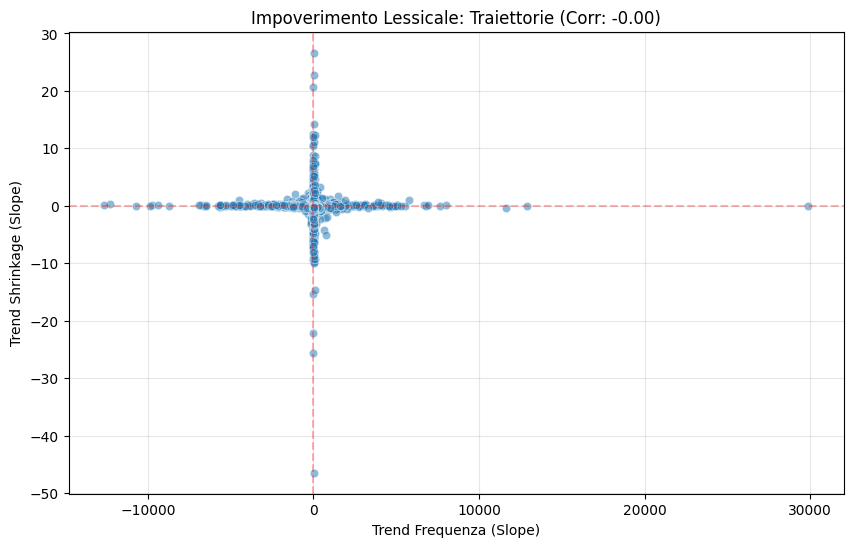

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns

# --- Caricamento shrinkage + frequenze ---
df_all = pd.read_csv("token_info_filtered_with_complexity_and_slope_norm.csv")

# Assumiamo che df_all contenga sia shrinkage che frequenze
df_shrink = df_all.copy()

results = []

tokens = df_shrink["token"].unique()
snapshots = range(1, 8)  # i tuoi snapshot

for token in tokens:
    row_shrink = df_shrink[df_shrink["token"] == token]
    
    y_shrink = []
    y_freq = []
    x_time = []
    
    for snap in snapshots:
        col_s = f"shrinkage_snap{snap}"
        col_f = f"freq_snap{snap}"
        
        # Recupero valori reali
        val_s = row_shrink[col_s].values[0] if col_s in row_shrink else np.nan
        val_f = df_all.loc[df_all["token"] == token, col_f].values[0] if col_f in df_all else np.nan
        
        if not np.isnan(val_s) and not np.isnan(val_f):
            y_shrink.append(val_s)
            y_freq.append(val_f)
            x_time.append(snap)
    
    if len(x_time) >= 4:  # almeno 4 snapshot validi
        slope_s, _, _, _, _ = linregress(x_time, y_shrink)
        slope_f, _, _, _, _ = linregress(x_time, y_freq)
        
        results.append({
            "token": token,
            "slope_shrinkage": slope_s,
            "slope_frequency": slope_f,
            # puoi aggiungere qui altre categorie se vuoi
        })

df_slopes = pd.DataFrame(results)

# --- 2. Analisi di Correlazione ---
corr = df_slopes["slope_frequency"].corr(df_slopes["slope_shrinkage"])
print(f"Correlazione tra Aumento Frequenza e Aumento Shrinkage: {corr:.4f}")

# --- 3. Visualizzazione (Scatter Plot) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_slopes, x="slope_frequency", y="slope_shrinkage", alpha=0.5)

# Linee degli assi per dividere i quadranti
plt.axhline(0, color='red', linestyle='--', alpha=0.3)
plt.axvline(0, color='red', linestyle='--', alpha=0.3)

plt.title(f"Impoverimento Lessicale: Traiettorie (Corr: {corr:.2f})")
plt.xlabel("Trend Frequenza (Slope)")
plt.ylabel("Trend Shrinkage (Slope)")
plt.grid(True, alpha=0.3)
plt.show()



In [91]:
# quando la frequenza cambia, lo shrinkage cosa fa?
from scipy.stats import spearmanr

rows = []

for snap in range(1, 7):
    df_s = pd.DataFrame({
        "Si": df_all[f"shrinkage_snap{snap}"],
        "delta_F": df_all[f"freq_snap{snap+1}"] - df_all[f"freq_snap{snap}"]
    }).dropna()

    if df_s["Si"].std() == 0 or df_s["delta_F"].std() == 0:
        continue

    rho, p = spearmanr(df_s["Si"], df_s["delta_F"])

    rows.append({
        "snap": snap,
        "spearman_rho": rho,
        "p_value": p,
        "n_tokens": len(df_s)
    })

df_corr_dyn = pd.DataFrame(rows)
df_corr_dyn


,snap,spearman_rho,p_value,n_tokens
0,2,0.012864,5.055229e-02,23104
1,3,0.037743,2.589491e-09,24885
2,4,0.024620,6.306265e-05,26404
3,5,0.008126,1.900358e-01,26008
4,6,0.010005,1.189329e-01,24288


In [ ]:
# import pandas as pd
# import numpy as np
# from pathlib import Path
# import igraph as ig

# # --- Percorsi ---
# shrink_csv = "semantic_shrinkage_clustering.csv"
# freq_dir = Path(r"../embedding/frequencies_all")
# sagg_file = Path(r"shrinkage_aggr_cc.csv")
# graph_dir = Path(r"networks_hybrid_annotated")
# output_csv = "token_cc_info_filtered_with_complexity_and_slope_norm.csv"

# snapshots = range(1, 8)

# # --- Carico shrinkage ---
# df_shrink = pd.read_csv(shrink_csv)

# # --- Carico frequenze per tutti gli snapshot ---
# freq_dfs = []
# for snap in snapshots:
#     freq_file = freq_dir / f"vocab_freq_snap{snap}.csv"

#     df_freq = pd.read_csv(freq_file)

#     df_freq = df_freq.rename(columns={
#         "word": "token",
#         "frequency": f"freq_snap{snap}"
#     })

#     df_freq["token"] = df_freq["token"].astype(str)
#     df_freq[f"freq_snap{snap}"] = df_freq[f"freq_snap{snap}"].astype(int)

#     freq_dfs.append(df_freq)

# # --- Merge di tutte le frequenze ---
# df_freq_all = freq_dfs[0]
# for df_f in freq_dfs[1:]:
#     df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# # --- Filtra token presenti in almeno 5 snapshot ---
# appear_count = (df_freq_all.iloc[:, 1:] > 0).sum(axis=1)
# df_freq_all = df_freq_all[appear_count >= 5]

# # --- Filtra df_shrink per token validi ---
# df_shrink = df_shrink[df_shrink["token"].isin(df_freq_all["token"])]

# # --- Merge shrinkage + frequenze ---
# df_all = df_shrink.merge(df_freq_all, on="token", how="inner")

# # --- Aggiungo S_aggregato ---
# df_sagg = pd.read_csv(sagg_file)
# df_all = df_all.merge(df_sagg, on="token", how="left")

# # --- COSTRUISCO COMPLESSITÀ ---
# complexity_data = {}

# for snap in snapshots:
#     graph_file = graph_dir / f"graph_snap{snap}_hybrid.igp"
#     G = ig.Graph.Read_Pickle(graph_file)

#     for v in G.vs:
#         token = v["token"]
#         if token not in complexity_data:
#             complexity_data[token] = {
#                 "char_len": v["char_len"],
#                 "syll_len": v["syll_len"],
#                 "demauro_level": v["demauro_level"],
#                 "idf": v["idf"]
#             }

# # --- Merge complessità ---
# df_complexity = (
#     pd.DataFrame.from_dict(complexity_data, orient="index")
#       .reset_index()
#       .rename(columns={"index": "token"})
# )
# df_all = df_all.merge(df_complexity, on="token", how="left")

# # =========================================================
# # === CALCOLO ANDAMENTO TEMPORALE DELLA FREQUENZA (ΔF) ===
# # =========================================================

# freq_cols = [f"freq_snap{snap}" for snap in snapshots]
# time = np.array(list(snapshots), dtype=float)

# def compute_slope(row):
#     y = row[freq_cols].values.astype(float)
#     if np.all(y == 0):
#         return 0.0
#     return np.polyfit(time, y, 1)[0]

# df_all["freq_slope"] = df_all.apply(compute_slope, axis=1)
# df_all["delta_F"] = df_all["freq_slope"] > 0

# # --- Salvataggio finale ---
# df_all.to_csv(output_csv, index=False)
# print(f"[DONE] CSV completo con complessità e ΔF creato in {output_csv}")


[DONE] CSV completo con complessità e ΔF creato in token_cc_info_filtered_with_complexity_and_slope_norm.csv


Correlazione tra Aumento Frequenza e Aumento Shrinkage: -0.0037


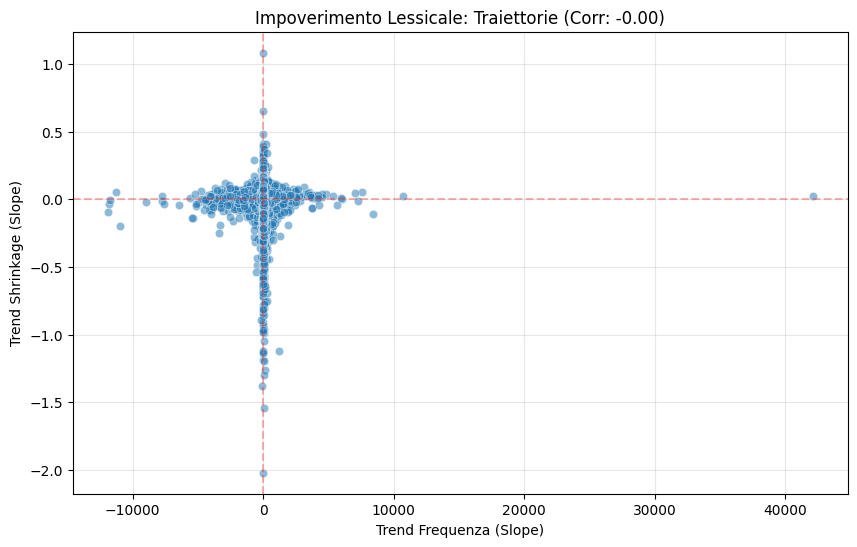

In [ ]:
# import pandas as pd
# import numpy as np
# from scipy.stats import linregress
# import matplotlib.pyplot as plt
# import seaborn as sns

# # --- Caricamento shrinkage + frequenze ---
# df_all = pd.read_csv("token_cc_info_filtered_with_complexity_and_slope_norm.csv")

# # Assumiamo che df_all contenga sia shrinkage che frequenze
# df_shrink = df_all.copy()

# results = []

# tokens = df_shrink["token"].unique()
# snapshots = range(1, 8)  # i tuoi snapshot

# for token in tokens:
#     row_shrink = df_shrink[df_shrink["token"] == token]
    
#     y_shrink = []
#     y_freq = []
#     x_time = []
    
#     for snap in snapshots:
#         col_s = f"shrinkage_snap{snap}"
#         col_f = f"freq_snap{snap}"
        
#         # Recupero valori reali
#         val_s = row_shrink[col_s].values[0] if col_s in row_shrink else np.nan
#         val_f = df_all.loc[df_all["token"] == token, col_f].values[0] if col_f in df_all else np.nan
        
#         if not np.isnan(val_s) and not np.isnan(val_f):
#             y_shrink.append(val_s)
#             y_freq.append(val_f)
#             x_time.append(snap)
    
#     if len(x_time) >= 4:  # almeno 4 snapshot validi
#         slope_s, _, _, _, _ = linregress(x_time, y_shrink)
#         slope_f, _, _, _, _ = linregress(x_time, y_freq)
        
#         results.append({
#             "token": token,
#             "slope_shrinkage": slope_s,
#             "slope_frequency": slope_f,
#             # puoi aggiungere qui altre categorie se vuoi
#         })

# df_slopes = pd.DataFrame(results)

# # --- 2. Analisi di Correlazione ---
# corr = df_slopes["slope_frequency"].corr(df_slopes["slope_shrinkage"])
# print(f"Correlazione tra Aumento Frequenza e Aumento Shrinkage: {corr:.4f}")

# # --- 3. Visualizzazione (Scatter Plot) ---
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df_slopes, x="slope_frequency", y="slope_shrinkage", alpha=0.5)

# # Linee degli assi per dividere i quadranti
# plt.axhline(0, color='red', linestyle='--', alpha=0.3)
# plt.axvline(0, color='red', linestyle='--', alpha=0.3)

# plt.title(f"Impoverimento Lessicale: Traiettorie (Corr: {corr:.2f})")
# plt.xlabel("Trend Frequenza (Slope)")
# plt.ylabel("Trend Shrinkage (Slope)")
# plt.grid(True, alpha=0.3)
# plt.show()



Parole più o meno shrinkate

In [57]:
df_all.loc[df_all["delta_F"], ["token", "S_aggregato", "delta_F"]].sort_values(
    "S_aggregato",
    ascending=False
).head(20)


,token,S_aggregato,delta_F
11878,iceberg,0.930625,True
20500,resa,0.790216,True
24644,super,0.776152,True
24173,staff,0.743852,True
19729,puma,0.723938,True
20417,relax,0.713842,True
16706,novità,0.711508,True
23886,spazio,0.707382,True
18922,pre,0.692611,True
21951,salvo,0.676430,True


In [19]:
df_all.loc[df_all["delta_F"], ["token", "S_aggregato", "delta_F"]].sort_values(
    "S_aggregato",
    ascending=True
).head(20)


,token,S_aggregato,delta_F
24734,plus,-42.853814,True
14665,lee,-40.262017,True
20331,triei,-25.428074,True
2554,pds,-15.044425,True
5016,cdl,-14.790516,True
7652,puma,-14.164609,True
14396,fiavè,-14.028503,True
24774,fuorché,-13.250417,True
23338,osé,-9.474589,True
10596,monaca,-9.349932,True


In [42]:
len(df_all[df_all["delta_F"] == True]) / len(df_all)

0.37612886578937665

In [43]:
len(df_all[df_all["delta_F"] == False]) / len(df_all)

0.6238711342106233

In [44]:
df_all["freq_slope"].describe()


count    20128.000000
mean        -8.658044
std        534.828459
min     -11885.892857
25%        -20.857143
50%          0.375000
75%         23.758929
max      42089.500000
Name: freq_slope, dtype: float64

In [21]:
from scipy.stats import zscore

df_all["S_aggregato_z"] = zscore(df_all["S_aggregato"], nan_policy="omit")
df_all["freq_slope_z"] = zscore(df_all["freq_slope"], nan_policy="omit")

df_all[["S_aggregato_z", "freq_slope_z"]].corr()


,S_aggregato_z,freq_slope_z
S_aggregato_z,1.000000,-0.008743
freq_slope_z,-0.008743,1.000000


In [20]:
df_all["S_aggregato"].corr(
    df_all["freq_slope"],
    method="spearman"
)


0.044286691177705964

In [22]:
import pandas as pd
import scipy.stats as stats

# --- Definizione eventi ---
df_all["S_positive"] = df_all["S_aggregato"] > 0
df_all["S_negative"] = df_all["S_aggregato"] < 0

# =================================================
# --- Probabilità condizionata delta_F=True / False ---
# =================================================

def cond_prob_stats(event_col):
    p_given_increase = df_all.loc[df_all["delta_F"], event_col].mean()
    p_given_no_increase = df_all.loc[~df_all["delta_F"], event_col].mean()
    p_marginal = df_all[event_col].mean()
    
    lift_f_pos = p_given_increase / p_marginal if p_marginal != 0 else float('nan')
    lift_f_neg = p_given_no_increase / p_marginal if p_marginal != 0 else float('nan')
    relative_risk = (p_given_increase / p_given_no_increase 
                     if p_given_no_increase != 0 else float('nan'))
    
    # Odds Ratio
    odds_inc = p_given_increase / (1 - p_given_increase) if p_given_increase not in [0,1] else float('nan')
    odds_no_inc = p_given_no_increase / (1 - p_given_no_increase) if p_given_no_increase not in [0,1] else float('nan')
    odds_ratio = (odds_inc / odds_no_inc) if (odds_inc not in [float('nan')] and odds_no_inc not in [float('nan')]) else float('nan')
    
    # chi2 test
    ct_raw = pd.crosstab(df_all["delta_F"], df_all[event_col])
    chi2, p_value, dof, expected = stats.chi2_contingency(ct_raw)
    
    # tabella condizionata
    ct = pd.crosstab(df_all["delta_F"], df_all[event_col], normalize="index")
    
    return {
        "p_given_increase": p_given_increase,
        "p_given_no_increase": p_given_no_increase,
        "p_marginal": p_marginal,
        "lift_f_pos": lift_f_pos,
        "lift_f_neg": lift_f_neg,
        "relative_risk": relative_risk,
        "odds_ratio": odds_ratio,
        "chi2": chi2,
        "p_value": p_value,
        "contingency_table": ct
    }

# --- Analisi per S_aggregato positivo ---
stats_positive = cond_prob_stats("S_positive")
print("\n=== S_aggregato > 0 ===")
print(stats_positive)

# --- Analisi per S_aggregato negativo ---
stats_negative = cond_prob_stats("S_negative")
print("\n=== S_aggregato < 0 ===")
print(stats_negative)



=== S_aggregato > 0 ===
{'p_given_increase': 0.18324350808427242, 'p_given_no_increase': 0.27445539878387154, 'p_marginal': 0.2401635720601238, 'lift_f_pos': 0.7629945978584891, 'lift_f_neg': 1.1427852959946938, 'relative_risk': 0.667662246384059, 'odds_ratio': 0.593100566808557, 'chi2': 289.83752783685554, 'p_value': 5.394579059954427e-65, 'contingency_table': S_positive     False     True 
delta_F                       
False       0.725545  0.274455
True        0.816756  0.183244}

=== S_aggregato < 0 ===
{'p_given_increase': 0.8167564919157276, 'p_given_no_increase': 0.7255446012161285, 'p_marginal': 0.7598364279398763, 'lift_f_pos': 1.0749109438332367, 'lift_f_neg': 0.9548694620805135, 'relative_risk': 1.1257150705093986, 'odds_ratio': 1.6860547029670663, 'chi2': 289.8375278368556, 'p_value': 5.394579059954273e-65, 'contingency_table': S_negative     False     True 
delta_F                       
False       0.274455  0.725545
True        0.183244  0.816756}


In [40]:
import pandas as pd
import scipy.stats as stats

# --- 1. Caricamento dati ---
# Shrinkage aggregato
df_shrink = pd.read_csv("shrinkage_aggr_filtered_norm.csv")

# Info token con livello De Mauro
freq_file = "token_info_filtered_with_complexity_and_slope_norm.csv"
df_info = pd.read_csv(freq_file)

# Merge sul token
df_all = df_shrink.merge(df_info[['token', 'demauro_level']], on='token', how='left')

# --- 2. Creazione indicatore VDB ---
# VDB=True se demauro_level != 3 (cioè è nel vocabolario di base)
df_all['VDB'] = df_all['demauro_level'] != 3

# --- 3. Creazione indicatori shrinkage positivo/negativo ---
df_all['S_positive'] = df_all['S_aggregato'] > 0  # perdita di connessioni
df_all['S_negative'] = df_all['S_aggregato'] < 0  # grado stabile o in aumento

# --- 4. Statistiche aggregate ---
# Shrinkage medio per gruppo
shrinkage_group = df_all.groupby('VDB')['S_aggregato'].describe()
print("Shrinkage medio e distribuzione per gruppo VDB vs non-VDB:\n", shrinkage_group)

# Probabilità di shrinkage positivo/negativo per gruppo
prob_positive = df_all.groupby('VDB')['S_positive'].mean()
prob_negative = df_all.groupby('VDB')['S_negative'].mean()
print("\nProbabilità shrinkage positivo per gruppo:\n", prob_positive)
print("\nProbabilità shrinkage negativo per gruppo:\n", prob_negative)

# --- 5. Analisi statistica: chi-quadrato e contingenza ---
ct_positive = pd.crosstab(df_all['VDB'], df_all['S_positive'])
chi2, p_value, dof, expected = stats.chi2_contingency(ct_positive)
print("\nTabella contingenza S_positive vs VDB:\n", ct_positive)
print(f"Chi2 = {chi2}, p-value = {p_value}")

ct_negative = pd.crosstab(df_all['VDB'], df_all['S_negative'])
chi2_neg, p_value_neg, dof_neg, expected_neg = stats.chi2_contingency(ct_negative)
print("\nTabella contingenza S_negative vs VDB:\n", ct_negative)
print(f"Chi2 = {chi2_neg}, p-value = {p_value_neg}")

# --- 6. Calcolo odds ratio e relative risk per S_positive ---
# Evitiamo divisione per zero aggiungendo piccola costante
epsilon = 1e-9

a = ct_positive.loc[True, True] if True in ct_positive.index else 0
b = ct_positive.loc[True, False] if True in ct_positive.index else 0
c = ct_positive.loc[False, True] if False in ct_positive.index else 0
d = ct_positive.loc[False, False] if False in ct_positive.index else 0

odds_vdb = (a + epsilon) / (b + epsilon)
odds_nonvdb = (c + epsilon) / (d + epsilon)
odds_ratio = odds_vdb / odds_nonvdb

risk_vdb = (a / (a + b + epsilon))
risk_nonvdb = (c / (c + d + epsilon))
relative_risk = risk_vdb / (risk_nonvdb + epsilon)

print(f"\nOdds Ratio S_positive VDB vs non-VDB: {odds_ratio}")
print(f"Relative Risk S_positive VDB vs non-VDB: {relative_risk}")


Shrinkage medio e distribuzione per gruppo VDB vs non-VDB:
          count      mean       std        min       25%       50%       75%  \
VDB                                                                           
False  20968.0 -0.307258  1.017257 -44.786682 -0.337194 -0.130756  0.008406   
True    6176.0 -0.237707  0.504835 -14.164609 -0.288940 -0.145129 -0.043582   

            max  
VDB              
False  0.883961  
True   0.624523  

Probabilità shrinkage positivo per gruppo:
 VDB
False    0.263592
True     0.160622
Name: S_positive, dtype: float64

Probabilità shrinkage negativo per gruppo:
 VDB
False    0.736408
True     0.839378
Name: S_negative, dtype: float64

Tabella contingenza S_positive vs VDB:
 S_positive  False  True 
VDB                     
False       15441   5527
True         5184    992
Chi2 = 276.6325716998492, p-value = 4.0684849243618805e-62

Tabella contingenza S_negative vs VDB:
 S_negative  False  True 
VDB                     
False        5527  15441

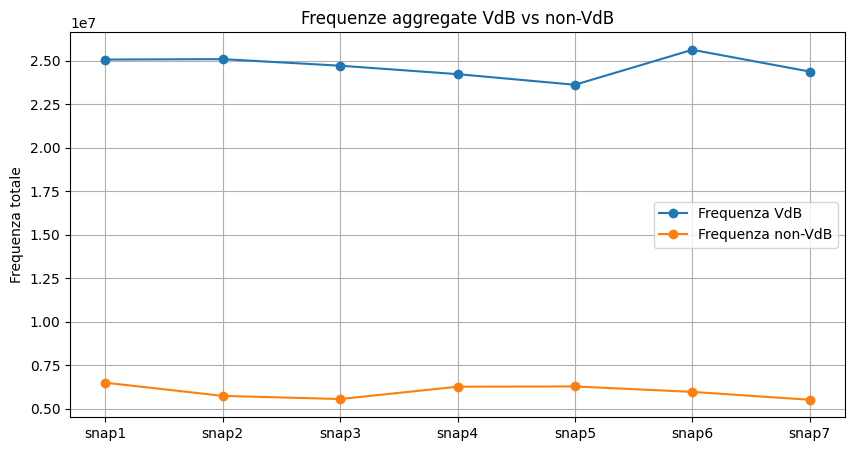

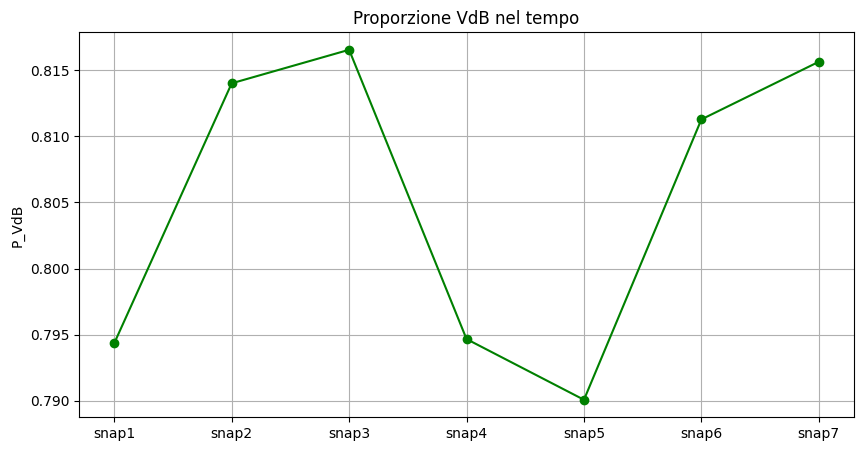

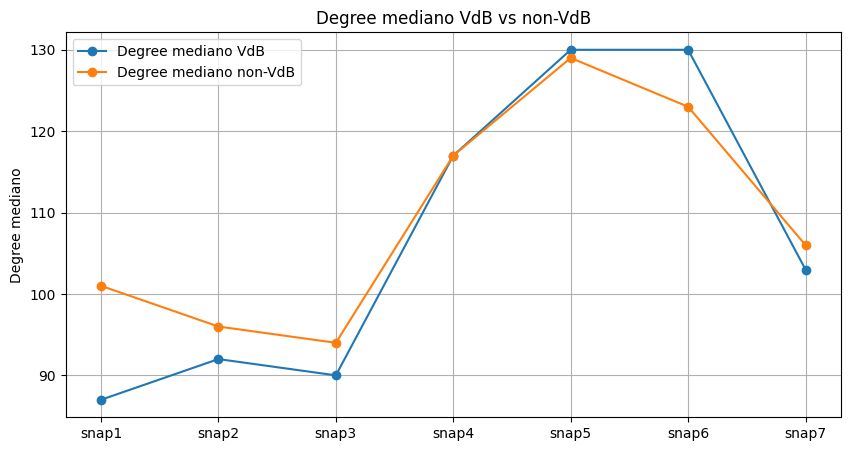

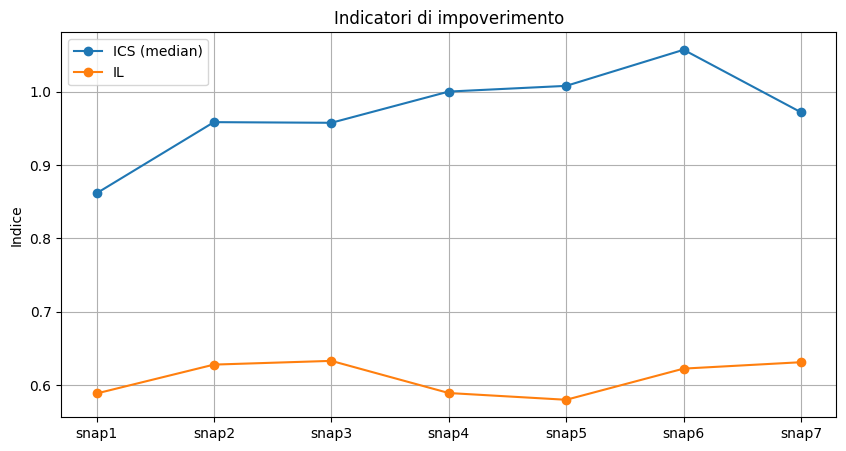

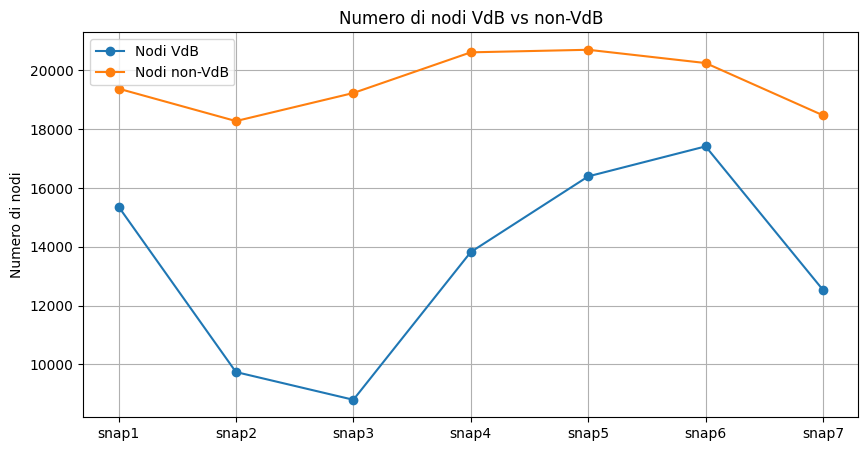

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# ----- 1️⃣ Percorsi dei file -----
freq_file = Path("token_info_filtered_with_complexity_and_slope_norm.csv")  # CSV con token, freq_snap1..7, demauro_level
degree_dir = Path("degree_csv_igraph_snapshot")  # directory con node_degree_snapX_hybrid.csv

snapshots = range(1, 8)

# ----- 2️⃣ Leggi il CSV delle frequenze -----
freq_df = pd.read_csv(freq_file)
freq_df['demauro_level'] = freq_df['demauro_level'].astype(int)

# ----- 3️⃣ Inizializza strutture per indicatori -----
P_VdB = []
F_VdB = []
F_nonVdB = []
degree_vdb_median = []
degree_nonvdb_median = []
ICS = []
IL = []
N_VdB = []
N_nonVdB = []

# ----- 4️⃣ Loop sugli snapshot -----
for snap in snapshots:
    freq_col = f"freq_snap{snap}"
    freq_snap = freq_df[[freq_col, "token", "demauro_level"]].copy()
    
    # Frequenze aggregate
    Fv = freq_snap.loc[freq_snap['demauro_level'] != 3, freq_col].sum()
    Fn = freq_snap.loc[freq_snap['demauro_level'] == 3, freq_col].sum()
    F_VdB.append(Fv)
    F_nonVdB.append(Fn)
    
    # Proporzione e indice impoverimento
    P_VdB.append(Fv / (Fv + Fn) if (Fv + Fn) > 0 else np.nan)
    IL.append((Fv - Fn) / (Fv + Fn) if (Fv + Fn) > 0 else np.nan)
    
    # Degree snapshot
    degree_file = degree_dir / f"node_degree_snap{snap}_hybrid.csv"
    deg_df = pd.read_csv(degree_file)
    merged = deg_df.merge(freq_df[['token', 'demauro_level']], on='token', how='left')
    
    # Degree mediano per entrambi i gruppi
    deg_vdb = merged.loc[merged['demauro_level'] != 3, 'degree']
    deg_nonvdb = merged.loc[merged['demauro_level'] == 3, 'degree']
    
    degree_vdb_median.append(deg_vdb.median() if not deg_vdb.empty else np.nan)
    degree_nonvdb_median.append(deg_nonvdb.median() if not deg_nonvdb.empty else np.nan)
    
    # ICS: rapporto mediane
    ICS.append((deg_vdb.median() / (deg_nonvdb.median()+1e-6)) if not deg_vdb.empty and not deg_nonvdb.empty else np.nan)
    
    # Numero di nodi
    N_VdB.append(len(deg_vdb))
    N_nonVdB.append(len(deg_nonvdb))

# ----- 5️⃣ Visualizzazioni -----
snap_labels = [f"snap{snap}" for snap in snapshots]

# Frequenze aggregate
plt.figure(figsize=(10,5))
plt.plot(snap_labels, F_VdB, marker='o', label='Frequenza VdB')
plt.plot(snap_labels, F_nonVdB, marker='o', label='Frequenza non-VdB')
plt.title("Frequenze aggregate VdB vs non-VdB")
plt.ylabel("Frequenza totale")
plt.legend()
plt.grid(True)
plt.show()

# Proporzione VdB
plt.figure(figsize=(10,5))
plt.plot(snap_labels, P_VdB, marker='o', color='green')
plt.title("Proporzione VdB nel tempo")
plt.ylabel("P_VdB")
plt.grid(True)
plt.show()

# Degree mediano VdB vs non-VdB
plt.figure(figsize=(10,5))
plt.plot(snap_labels, degree_vdb_median, marker='o', label='Degree mediano VdB')
plt.plot(snap_labels, degree_nonvdb_median, marker='o', label='Degree mediano non-VdB')
plt.title("Degree mediano VdB vs non-VdB")
plt.ylabel("Degree mediano")
plt.legend()
plt.grid(True)
plt.show()

# ICS e IL
plt.figure(figsize=(10,5))
plt.plot(snap_labels, ICS, marker='o', label='ICS (median)')
plt.plot(snap_labels, IL, marker='o', label='IL')
plt.title("Indicatori di impoverimento")
plt.ylabel("Indice")
plt.legend()
plt.grid(True)
plt.show()

# Numero di nodi per gruppo
plt.figure(figsize=(10,5))
plt.plot(snap_labels, N_VdB, marker='o', label='Nodi VdB')
plt.plot(snap_labels, N_nonVdB, marker='o', label='Nodi non-VdB')
plt.title("Numero di nodi VdB vs non-VdB")
plt.ylabel("Numero di nodi")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
# ----- 6️⃣ Stampa valori principali per ciascun snapshot -----
print("\nValori principali per snapshot:\n")
print(f"{'Snap':<6} {'F_VdB':>10} {'F_nonVdB':>10} {'P_VdB':>8} {'IL':>8} "
      f"{'Degree_VdB_med':>15} {'Degree_nonVdB_med':>18} {'ICS':>8} "
      f"{'N_VdB':>6} {'N_nonVdB':>10}")

for i, snap in enumerate(snapshots):
    print(f"{snap_labels[i]:<6} "
          f"{F_VdB[i]:>10.1f} "
          f"{F_nonVdB[i]:>10.1f} "
          f"{P_VdB[i]:>8.3f} "
          f"{IL[i]:>8.3f} "
          f"{degree_vdb_median[i]:>15.2f} "
          f"{degree_nonvdb_median[i]:>18.2f} "
          f"{ICS[i]:>8.2f} "
          f"{N_VdB[i]:>6} "
          f"{N_nonVdB[i]:>10}")



Valori principali per snapshot:

Snap        F_VdB   F_nonVdB    P_VdB       IL  Degree_VdB_med  Degree_nonVdB_med      ICS  N_VdB   N_nonVdB
snap1  25060122.0  6488003.0    0.794    0.589           87.00             101.00     0.86  15367      19375
snap2  25084911.0  5731144.0    0.814    0.628           92.00              96.00     0.96   9744      18273
snap3  24707976.0  5550639.0    0.817    0.633           90.00              94.00     0.96   8801      19227
snap4  24221955.0  6259033.0    0.795    0.589          117.00             117.00     1.00  13822      20609
snap5  23611741.0  6274217.0    0.790    0.580          130.00             129.00     1.01  16393      20696
snap6  25622480.0  5959946.0    0.811    0.623          130.00             123.00     1.06  17413      20245
snap7  24368961.0  5507693.0    0.816    0.631          103.00             106.00     0.97  12532      18468


In [27]:
from scipy.stats import mannwhitneyu, spearmanr

# 1️⃣ Mann-Whitney degree VdB vs non-VdB snapshot 4 (esempio)
deg_vdb_snap4 = merged.loc[merged['demauro_level'] != 3, 'degree']
deg_nonvdb_snap4 = merged.loc[merged['demauro_level'] == 3, 'degree']
stat, p = mannwhitneyu(deg_vdb_snap4, deg_nonvdb_snap4, alternative='two-sided')
print(f"Snap4 degree VdB vs non-VdB: U={stat}, p={p:.5f}")

# 2️⃣ Spearman trend P_VdB nel tempo
rho, p_trend = spearmanr(range(1,8), P_VdB)
print(f"Trend P_VdB: rho={rho:.3f}, p={p_trend:.5f}")

# 3️⃣ Bootstrap ICS
def bootstrap_median_ratio(vdb, nonvdb, n_boot=10000):
    ratios = []
    for _ in range(n_boot):
        sample_vdb = np.random.choice(vdb, size=len(vdb), replace=True)
        sample_nonvdb = np.random.choice(nonvdb, size=len(nonvdb), replace=True)
        ratios.append(np.median(sample_vdb) / (np.median(sample_nonvdb)+1e-6))
    return np.percentile(ratios, [2.5, 97.5])

ci_ics_snap4 = bootstrap_median_ratio(deg_vdb_snap4, deg_nonvdb_snap4)
print(f"ICS snap4 95% CI: {ci_ics_snap4}")


Snap4 degree VdB vs non-VdB: U=115512395.5, p=0.78784
Trend P_VdB: rho=0.143, p=0.75995
ICS snap4 95% CI: [0.95283018 1.0095238 ]


# Expand RQ1 with complexity
Analyze the aggregated shrinkage (S_aggr) and the complexity metrics of the tokens.

In [62]:
# --- shrink finale per token
df = df_all.copy()
df["shrink_final"] = df["S_aggregato"] < 0

df_token = (
    df.groupby("token", as_index=False)
      .agg(shrink_final=("shrink_final", "any"),
           S_aggregato=("S_aggregato", "min"))
)

# --- carica CSV De Mauro
token_info = pd.read_csv("token_info_filtered_with_complexity.csv")

token_info = token_info[["token", "demauro_level"]]

# --- merge
df_final = df_token.merge(token_info, on="token", how="left")

# --- conta
df_shrink_final = df_final[df_final["shrink_final"]]

n_shrink_final = len(df_shrink_final)
n_complex_shrink_final = (df_shrink_final["demauro_level"] == 3).sum()

print("Token con S_aggregato < 0:", n_shrink_final)
print("Token complessi (De Mauro = 3):", n_complex_shrink_final)
print("P(complessa | shrink finale):", n_complex_shrink_final / n_shrink_final)


p_complex_base = (token_info["demauro_level"] == 3).mean()
print(p_complex_base)


p_complex_given_shrink = n_complex_shrink_final / n_shrink_final
p_complex_base = (token_info["demauro_level"] == 3).mean()

lift = p_complex_given_shrink / p_complex_base

print("P(complessa | shrink finale):", p_complex_given_shrink)
print("P(complessa) base-rate:", p_complex_base)
print("Lift:", lift)




Token con S_aggregato < 0: 14138
Token complessi (De Mauro = 3): 11141
P(complessa | shrink finale): 0.7880181072287452
0.7723469350141915
P(complessa | shrink finale): 0.7880181072287452
P(complessa) base-rate: 0.7723469350141915
Lift: 1.0202903274475554


In [63]:
import pandas as pd
import scipy.stats as stats

# --- Shrink finale per token ---
df = df_all.copy()
df["shrink_final"] = df["S_aggregato"] < 0

df_token = (
    df.groupby("token", as_index=False)
      .agg(shrink_final=("shrink_final", "any"),
           S_aggregato=("S_aggregato", "min"))
)

# --- Carica CSV De Mauro ---
token_info = pd.read_csv("token_info_filtered_with_complexity.csv")
token_info = token_info[["token", "demauro_level"]]

# --- Merge con De Mauro ---
df_final = df_token.merge(token_info, on="token", how="left")

# --- Definizione evento: complesso De Mauro = 3 ---
df_final["is_complex"] = df_final["demauro_level"] == 3

# =================================================
# --- Funzione per probabilità condizionata ---
# =================================================
def cond_prob_stats(event_col):
    p_given_shrink = df_final.loc[df_final["shrink_final"], event_col].mean()
    p_given_no_shrink = df_final.loc[~df_final["shrink_final"], event_col].mean()
    p_marginal = df_final[event_col].mean()
    
    lift = p_given_shrink / p_marginal if p_marginal != 0 else float('nan')
    relative_risk = (p_given_shrink / p_given_no_shrink 
                     if p_given_no_shrink != 0 else float('nan'))
    
    # Odds Ratio
    odds_shrink = p_given_shrink / (1 - p_given_shrink) if p_given_shrink not in [0,1] else float('nan')
    odds_no_shrink = p_given_no_shrink / (1 - p_given_no_shrink) if p_given_no_shrink not in [0,1] else float('nan')
    odds_ratio = (odds_shrink / odds_no_shrink) if (odds_shrink not in [float('nan')] and odds_no_shrink not in [float('nan')]) else float('nan')
    
    # chi2 test
    ct_raw = pd.crosstab(df_final["shrink_final"], df_final[event_col])
    chi2, p_value, dof, expected = stats.chi2_contingency(ct_raw)
    
    # tabella condizionata
    ct = pd.crosstab(df_final["shrink_final"], df_final[event_col], normalize="index")
    
    return {
        "p_given_shrink": p_given_shrink,
        "p_given_no_shrink": p_given_no_shrink,
        "p_marginal": p_marginal,
        "lift": lift,
        "relative_risk": relative_risk,
        "odds_ratio": odds_ratio,
        "chi2": chi2,
        "p_value": p_value,
        "contingency_table": ct
    }

# --- Analisi complessità De Mauro ---
stats_complex = cond_prob_stats("is_complex")

print("\n=== Analisi De Mauro (complessità livello 3) | shrink finale ===")
print(stats_complex)



=== Analisi De Mauro (complessità livello 3) | shrink finale ===
{'p_given_shrink': 0.7880181072287452, 'p_given_no_shrink': 0.7544210364447178, 'p_marginal': 0.7719201296787503, 'lift': 1.0208544601067657, 'relative_risk': 1.0445335815957053, 'odds_ratio': 1.2100820075409013, 'chi2': 43.240537247724816, 'p_value': 4.8407315381068956e-11, 'contingency_table': is_complex       False     True 
shrink_final                    
False         0.245579  0.754421
True          0.211982  0.788018}


# Weight edge study 

In [21]:
import igraph as ig
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Directory dei grafi
graph_dir = Path(r"networks_hybrid")
graph_files = sorted(graph_dir.glob("graph_snap*_hybrid.igp"))

all_weights = []
heavy_edges_info = []

percentile_heavy = 95  # soglia per archi pesanti

print(f"[START] Analisi di {len(graph_files)} snapshot")

for i, gf in enumerate(graph_files, start=1):
    print(f"\n[SNAPSHOT {i}/{len(graph_files)}] Caricamento {gf.name}")
    g = ig.Graph.Read_Pickle(gf)

    if "weight" not in g.es.attribute_names():
        print("Nessun peso sugli archi, salto snapshot")
        continue

    weights = np.array(g.es["weight"])
    all_weights.extend(weights)

    threshold = np.percentile(weights, percentile_heavy)
    heavy_edges = [e.index for e in g.es if e["weight"] >= threshold]

    print(f"Totale archi: {g.ecount()}, archi pesanti (> {percentile_heavy}° percentile): {len(heavy_edges)}")

    for e_idx in heavy_edges:
        e = g.es[e_idx]
        src, dst = e.tuple
        heavy_edges_info.append({
            "snapshot": gf.stem,
            "source": g.vs[src]["token"],
            "target": g.vs[dst]["token"],
            "weight": e["weight"]
        })

print("\n[END] Analisi completata su tutti gli snapshot")



# # ---------- Archi pesanti ----------
# df_heavy = pd.DataFrame(heavy_edges_info)
# print("\nTop 20 archi più pesanti:")
# print(df_heavy.sort_values("weight", ascending=False).head(20))


[START] Analisi di 7 snapshot

[SNAPSHOT 1/7] Caricamento graph_snap1_hybrid.igp
Totale archi: 3033079, archi pesanti (> 95° percentile): 151654

[SNAPSHOT 2/7] Caricamento graph_snap2_hybrid.igp
Totale archi: 1985640, archi pesanti (> 95° percentile): 99282

[SNAPSHOT 3/7] Caricamento graph_snap3_hybrid.igp
Totale archi: 1930980, archi pesanti (> 95° percentile): 96550

[SNAPSHOT 4/7] Caricamento graph_snap4_hybrid.igp
Totale archi: 3011365, archi pesanti (> 95° percentile): 150569

[SNAPSHOT 5/7] Caricamento graph_snap5_hybrid.igp
Totale archi: 3482725, archi pesanti (> 95° percentile): 174137

[SNAPSHOT 6/7] Caricamento graph_snap6_hybrid.igp
Totale archi: 3604324, archi pesanti (> 95° percentile): 180220

[SNAPSHOT 7/7] Caricamento graph_snap7_hybrid.igp
Totale archi: 2390413, archi pesanti (> 95° percentile): 119522

[END] Analisi completata su tutti gli snapshot


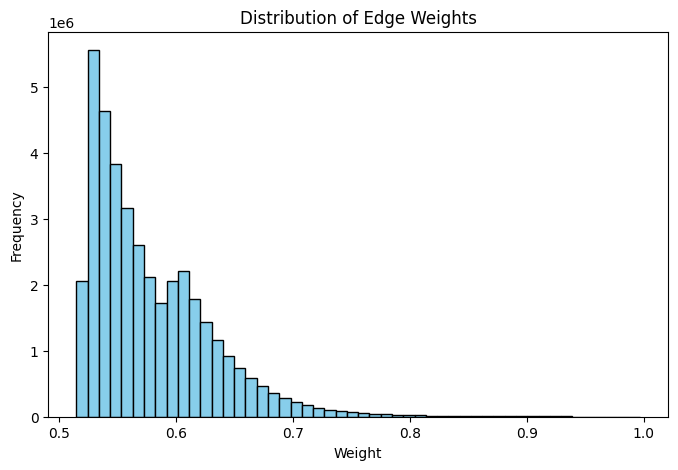

In [ ]:
all_weights = np.array(all_weights)

plt.figure(figsize=(8,5))
plt.hist(all_weights, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Edge Weights")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()


<Figure size 1600x600 with 0 Axes>

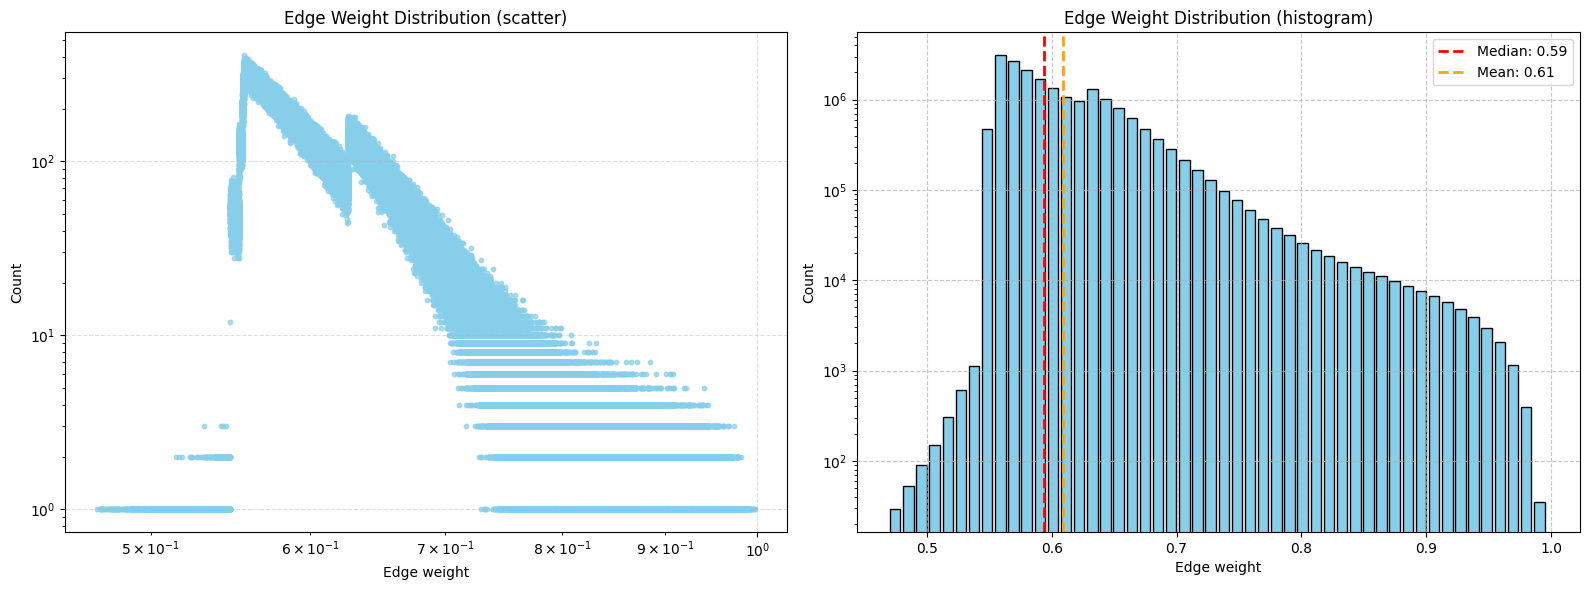

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Supponiamo che all_weights sia già un array numpy
all_weights = np.array(all_weights)

# Contiamo la frequenza di ogni peso
unique_weights, counts = np.unique(all_weights, return_counts=True)

# Histogram bins simili a quelli usati per i gradi
bin_width = (all_weights.max() - all_weights.min()) / 50  # 50 bins
bins = np.arange(all_weights.min(), all_weights.max() + bin_width, bin_width)

plt.figure(figsize=(16,6))
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# --- Scatter plot ---
axes[0].scatter(unique_weights, counts, alpha=0.7, s=10, color='skyblue')
axes[0].set_xlabel("Edge weight")
axes[0].set_ylabel("Count")
axes[0].set_title("Edge Weight Distribution (scatter)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].grid(True, linestyle="--", alpha=0.4)

# --- Histogram ---
axes[1].hist(all_weights, bins=bins, color='skyblue', edgecolor='black', width=bin_width*0.8)
median_weight = np.median(all_weights)
mean_weight = np.mean(all_weights)

axes[1].axvline(median_weight, color='red', linestyle='--', linewidth=2, label=f"Median: {median_weight:.2f}")
axes[1].axvline(mean_weight, color='orange', linestyle='--', linewidth=2, label=f"Mean: {mean_weight:.2f}")

axes[1].set_xlabel("Edge weight")
axes[1].set_ylabel("Count")
axes[1].set_title("Edge Weight Distribution (histogram)")
axes[1].set_yscale("log")
axes[1].grid(True, linestyle="--", alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()


In [23]:
# Mostrare tutte le righe senza troncamento
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)  # larghezza del terminale
pd.set_option("display.max_colwidth", None)

# ---------- Archi pesanti ----------
df_heavy = pd.DataFrame(heavy_edges_info)
print("\nTop 300 archi più pesanti:")
print(df_heavy.sort_values("weight", ascending=False).head(300))



Top 300 archi più pesanti:
                  snapshot                source               target    weight
527897  graph_snap5_hybrid              mmmmmmmm              mmmmmmm  0.996928
606002  graph_snap5_hybrid                mmmmmm              mmmmmmm  0.996261
596701  graph_snap5_hybrid    fondicriinternazre     fondicriinternaz  0.995070
133820  graph_snap1_hybrid    autoferrotranviero   autoferrotranviere  0.995024
733297  graph_snap6_hybrid        teatridithalia       teatridithalio  0.994066
431289  graph_snap4_hybrid    autoferrotranviero   autoferrotranviere  0.993182
325587  graph_snap3_hybrid    autoferrotranviero   autoferrotranviere  0.992464
153819  graph_snap2_hybrid    autoferrotranviero   autoferrotranviere  0.991648
588333  graph_snap5_hybrid         antimeridiana        antimeridiano  0.991603
552848  graph_snap5_hybrid           capitalgest           capitalges  0.991446
498310  graph_snap5_hybrid         phenixfundtop           phenixfund  0.991311
3469    grap

# Rich-get-richer + shrinking core + centralizzazione dei nodi high-frequency/generici + displacement dei termini specifici.

In [31]:
import pandas as pd
import numpy as np
import igraph as ig
from pathlib import Path
from scipy.stats import spearmanr, mannwhitneyu
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# -----------------------
# PATH
# -----------------------
freq_file = Path("token_info_filtered_with_complexity_and_slope_norm.csv")
graph_dir = Path("networks_hybrid")

# -----------------------
# FUNZIONI
# -----------------------

def gini(array):
    array = np.asarray(array, dtype=np.float64)
    if len(array) == 0:
        return np.nan
    if np.amin(array) < 0:
        array = array - np.amin(array)
    array = array + 1e-9
    array = np.sort(array)
    n = array.shape[0]
    index = np.arange(1, n + 1)
    return ((2 * np.sum(index * array)) / (n * np.sum(array))) - ((n + 1) / n)

def core_share(degrees, top_percent=0.05):
    degrees = np.asarray(degrees)
    if len(degrees) == 0:
        return np.nan
    k = max(1, int(len(degrees) * top_percent))
    sorted_deg = np.sort(degrees)[::-1]
    return sorted_deg[:k].sum() / sorted_deg.sum()

# -----------------------
# CARICA FREQUENZE
# -----------------------
freq_df = pd.read_csv(freq_file)
freq_df = freq_df.dropna(subset=["demauro_level"])
freq_df["demauro_level"] = freq_df["demauro_level"].astype(int)
freq_df["is_VdB"] = (freq_df["demauro_level"] != 3).astype(int)

# -----------------------
# STORAGE RISULTATI
# -----------------------
results = []

# -----------------------
# LOOP TEMPORALE
# -----------------------

for t in range(1, 7):

    print(f"\n========== SNAP {t} → {t+1} ==========")

    # ---- Carica grafi
    g_t = ig.Graph.Read_Pickle(graph_dir / f"graph_snap{t}_hybrid.igp")
    g_next = ig.Graph.Read_Pickle(graph_dir / f"graph_snap{t+1}_hybrid.igp")

    deg_t = pd.DataFrame({
        "token": g_t.vs["token"],
        "degree_t": g_t.degree()
    })

    deg_next = pd.DataFrame({
        "token": g_next.vs["token"],
        "degree_next": g_next.degree()
    })

    df = deg_t.merge(deg_next, on="token", how="inner")
    df["delta_degree"] = df["degree_next"] - df["degree_t"]

    # ---- Merge frequenze
    df = df.merge(
        freq_df[["token", f"freq_snap{t}", f"freq_snap{t+1}", "is_VdB"]],
        on="token",
        how="left"
    )

    df["delta_freq"] = df[f"freq_snap{t+1}"] - df[f"freq_snap{t}"]

    # ---- Pulizia globale per analisi numeriche
    df = df.replace([np.inf, -np.inf], np.nan)

    # ======================================
    # 1️⃣ Preferential Attachment
    # ======================================
    pa_df = df.dropna(subset=["degree_t", "delta_degree"])
    rho_pa, p_pa = spearmanr(pa_df["degree_t"], pa_df["delta_degree"])
    print(f"Preferential attachment: rho={rho_pa:.4f}, p={p_pa:.5f}")

    # ======================================
    # 2️⃣ Gini
    # ======================================
    gini_t = gini(pa_df["degree_t"])
    gini_next = gini(pa_df["degree_next"])
    print(f"Gini_t={gini_t:.4f}, Gini_next={gini_next:.4f}, Δ={gini_next-gini_t:.4f}")

    # ======================================
    # 3️⃣ Core concentration
    # ======================================
    core_t = core_share(pa_df["degree_t"])
    core_next = core_share(pa_df["degree_next"])
    print(f"Core share 5%: t={core_t:.4f}, next={core_next:.4f}")

    # ======================================
    # 4️⃣ Regressione Δdegree
    # ======================================
    reg_df = df.dropna(subset=["degree_t", f"freq_snap{t}", "is_VdB", "delta_degree"])

    X = reg_df[["degree_t", f"freq_snap{t}", "is_VdB"]]
    X = sm.add_constant(X)
    y = reg_df["delta_degree"]

    model = sm.OLS(y, X).fit()
    print(model.summary().tables[1])
    print(f"N regression: {len(reg_df)}")

    # ======================================
    # 5️⃣ Penalizzazione non-VdB
    # ======================================
    delta_vdb = reg_df.loc[reg_df["is_VdB"] == 1, "delta_degree"]
    delta_non = reg_df.loc[reg_df["is_VdB"] == 0, "delta_degree"]

    if len(delta_vdb) > 0 and len(delta_non) > 0:
        stat, p_mw = mannwhitneyu(delta_vdb, delta_non, alternative="two-sided")
    else:
        p_mw = np.nan

    print(f"Mann-Whitney Δdegree VdB vs non-VdB: p={p_mw:.5f}")

    # ======================================
    # 6️⃣ Displacement verso core
    # ======================================
    threshold = np.percentile(pa_df["degree_t"], 95)
    core_nodes = set(pa_df.loc[pa_df["degree_t"] >= threshold, "token"])

    token_to_idx_t = {v["token"]: v.index for v in g_t.vs}
    token_to_idx_next = {v["token"]: v.index for v in g_next.vs}

    shift_to_core = []

    for token in pa_df["token"]:
        if token not in token_to_idx_t or token not in token_to_idx_next:
            shift_to_core.append(np.nan)
            continue

        idx_t = token_to_idx_t[token]
        idx_next = token_to_idx_next[token]

        neighbors_t = [g_t.vs[n]["token"] for n in g_t.neighbors(idx_t)]
        neighbors_next = [g_next.vs[n]["token"] for n in g_next.neighbors(idx_next)]

        core_ties_t = sum(1 for n in neighbors_t if n in core_nodes)
        core_ties_next = sum(1 for n in neighbors_next if n in core_nodes)

        shift_to_core.append(core_ties_next - core_ties_t)

    mean_shift = np.nanmean(shift_to_core)
    print(f"Mean shift toward core: {mean_shift:.4f}")

    # ---- Salva risultati
    results.append({
        "snap": f"{t}->{t+1}",
        "rho_pa": rho_pa,
        "p_pa": p_pa,
        "gini_t": gini_t,
        "gini_next": gini_next,
        "core_share_t": core_t,
        "core_share_next": core_next,
        "mw_p": p_mw,
        "mean_shift_core": mean_shift
    })

# -----------------------
# SUMMARY
# -----------------------
print("\n===== SUMMARY =====")
summary_df = pd.DataFrame(results)
print(summary_df)



========== SNAP 1 → 2 ==========
Preferential attachment: rho=-0.4547, p=0.00000
Gini_t=0.5648, Gini_next=0.5024, Δ=-0.0624
Core share 5%: t=0.2641, next=0.2185
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         60.4162      1.013     59.638      0.000      58.431      62.402
degree_t      -0.5305      0.003   -160.694      0.000      -0.537      -0.524
freq_snap1  -3.99e-05   6.67e-05     -0.598      0.550      -0.000    9.09e-05
is_VdB         2.8322      1.654      1.712      0.087      -0.410       6.074
N regression: 23325
Mann-Whitney Δdegree VdB vs non-VdB: p=0.00000
Mean shift toward core: -11.1927

========== SNAP 2 → 3 ==========
Preferential attachment: rho=-0.3055, p=0.00000
Gini_t=0.4977, Gini_next=0.4973, Δ=-0.0004
Core share 5%: t=0.2162, next=0.2158
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

# new rq1

[START] Analisi RQ1 - Correzione Mapping Chiavi
Snap 1 elaborato correttamente.
Snap 2 elaborato correttamente.
Snap 3 elaborato correttamente.
Snap 4 elaborato correttamente.
Snap 5 elaborato correttamente.
Snap 6 elaborato correttamente.
Snap 7 elaborato correttamente.


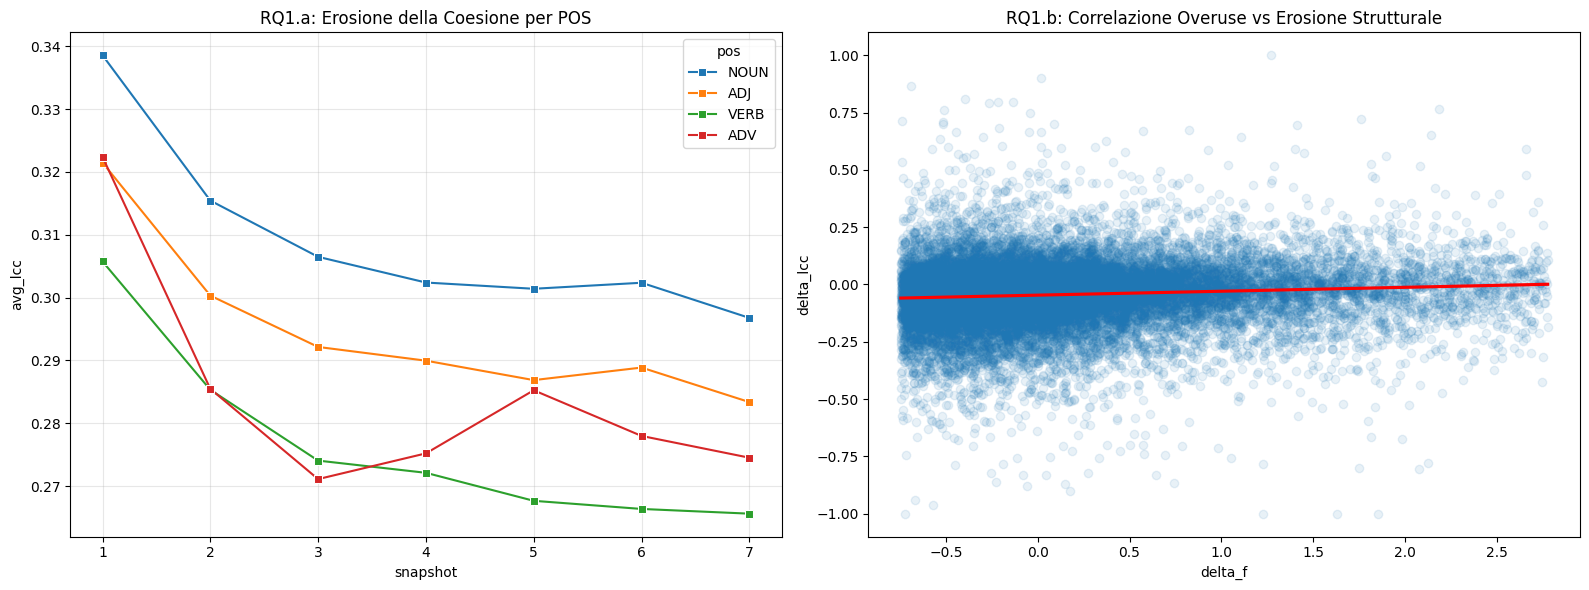


Pearson r: 0.0325
P-value T-test (Crescita Alta vs Bassa): 9.6501e-45


In [5]:
import igraph as ig
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

# --- SETUP NLP ---
try:
    nlp = spacy.load("it_core_news_sm", disable=["parser", "ner", "lemmatizer"])
except:
    import os
    os.system("python -m spacy download it_core_news_sm")
    nlp = spacy.load("it_core_news_sm", disable=["parser", "ner", "lemmatizer"])

input_dir = Path("networks_hybrid_annotated")
stats_timeline = []
snap_data = {}

print("[START] Analisi RQ1 - Correzione Mapping Chiavi")

for snap in range(1, 8):
    file_path = input_dir / f"graph_snap{snap}_hybrid.igp"
    if not file_path.exists(): continue
    
    g = ig.Graph.Read_Pickle(str(file_path))
    
    # 1. Ricostruzione LCC (Sempre necessaria se non salvata)
    g.vs["lcc"] = g.transitivity_local_undirected(mode="zero")
    
    # 2. Ricostruzione POS (Fondamentale per il KeyError)
    if "pos" not in g.vs.attributes():
        tokens = g.vs["token"] if "token" in g.vs.attributes() else g.vs["name"]
        g.vs["pos"] = [doc[0].pos_ for doc in nlp.pipe(tokens, batch_size=1000)]
    
    # 3. Controllo Frequenza
    if "freq" not in g.vs.attributes():
        g.vs["freq"] = g.degree()
    
    # 4. Calcolo KNN (Per la vulnerabilità strutturale)
    # Calcoliamo la forza dei vicini per vedere se i nodi si connettono a "periferie"
    strengths = np.array(g.strength(weights=g.es["weight"]) if "weight" in g.es.attributes() else g.degree())
    adj_list = g.get_adjlist()
    g.vs["knn"] = [np.mean(strengths[neighbors]) if neighbors else 0 for neighbors in adj_list]
    
    # 5. Archiviazione Dati (USO CHIAVI ESTESE PER EVITARE KEYERROR)
    id_attr = "token" if "token" in g.vs.attributes() else "name"
    snap_data[snap] = {
        v[id_attr]: {
            "freq": v["freq"], 
            "lcc": v["lcc"], 
            "pos": v["pos"],
            "knn": v["knn"]
        } for v in g.vs
    }
    
    # Aggregazione per RQ1.a
    for pos_tag in ['NOUN', 'ADJ', 'VERB', 'ADV']:
        sub = g.vs.select(pos=pos_tag)
        if len(sub) > 0:
            stats_timeline.append({
                "snapshot": snap,
                "pos": pos_tag,
                "avg_lcc": np.mean(sub["lcc"]),
                "avg_knn": np.mean(sub["knn"])
            })
    
    print(f"Snap {snap} elaborato correttamente.")

# --- 6. ANALISI CORRELAZIONE (RQ1.b) ---
if 1 in snap_data and 7 in snap_data:
    deltas = []
    for token, d1 in snap_data[1].items():
        if token in snap_data[7]:
            d7 = snap_data[7][token]
            
            # Calcolo variazioni tra inizio e fine
            deltas.append({
                "token": token,
                "pos": d1["pos"], # Ora la chiave 'pos' esiste sicuramente
                "delta_f": (d7["freq"] - d1["freq"]) / (d1["freq"] + 0.001),
                "delta_lcc": d7["lcc"] - d1["lcc"]
            })
    
    df_rq1b = pd.DataFrame(deltas)

    # --- VISUALIZZAZIONE ---
    plt.figure(figsize=(16, 6))

    # Grafico RQ1.a: Evoluzione temporale PoS
    plt.subplot(1, 2, 1)
    df_plot_a = pd.DataFrame(stats_timeline)
    sns.lineplot(data=df_plot_a, x="snapshot", y="avg_lcc", hue="pos", marker="s")
    plt.title("RQ1.a: Erosione della Coesione per POS")
    plt.grid(True, alpha=0.3)

    # Grafico RQ1.b: Relazione Frequenza/Erosione
    plt.subplot(1, 2, 2)
    # Filtro outlier per rendere il grafico leggibile
    df_f = df_rq1b[df_rq1b['delta_f'].between(df_rq1b['delta_f'].quantile(0.05), df_rq1b['delta_f'].quantile(0.95))]
    sns.regplot(data=df_f, x="delta_f", y="delta_lcc", scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
    plt.title("RQ1.b: Correlazione Overuse vs Erosione Strutturale")
    
    plt.tight_layout()
    plt.show()

    # --- TEST STATISTICO FINALE ---
    high_growth = df_rq1b[df_rq1b["delta_f"] > df_rq1b["delta_f"].median()]
    low_growth = df_rq1b[df_rq1b["delta_f"] <= df_rq1b["delta_f"].median()]
    t_stat, p_val = stats.ttest_ind(high_growth["delta_lcc"], low_growth["delta_lcc"])
    
    print(f"\nPearson r: {df_rq1b['delta_f'].corr(df_rq1b['delta_lcc']):.4f}")
    print(f"P-value T-test (Crescita Alta vs Bassa): {p_val:.4e}")

In [7]:
import pandas as pd

# 1. Calcoliamo i due estremi per il confronto
# Gruppo A: Le parole "di moda" (Top 1% per crescita di frequenza)
overused_examples = df_rq1b.nlargest(10, 'delta_f')

# Gruppo B: Le parole "stabili" (crescita vicina allo zero)
stable_examples = df_rq1b[df_rq1b['delta_f'].abs() < 0.05].head(10)

print("--- CASE STUDIES: PAROLE 'DI MODA' (OVERUSE) ---")
print(overused_examples[['token', 'pos', 'delta_f', 'delta_lcc']])

print("\n--- CASE STUDIES: PAROLE STABILI ---")
print(stable_examples[['token', 'pos', 'delta_f', 'delta_lcc']])

--- CASE STUDIES: PAROLE 'DI MODA' (OVERUSE) ---
              token   pos     delta_f  delta_lcc
13398    berluscone  NOUN  486.016456  -0.115552
9097           euro  NOUN  144.411397  -0.154759
21391          iraq   ADJ  119.832282   0.052990
12789      islamico   ADJ   76.451008   0.100938
8489         casine  NOUN   74.816822  -0.126561
19625      nuvoloso   ADJ   68.828429   0.333236
19219       bersani  NOUN   66.492643  -0.155600
23435  rifondazione  NOUN   58.160590   0.088926
22934   federalismo  NOUN   48.544351  -0.359299
17468     condiviso  VERB   44.890679  -0.080489

--- CASE STUDIES: PAROLE STABILI ---
              token   pos   delta_f  delta_lcc
27     qualunquista  PRON  0.014706  -0.119822
42       sofferente   ADJ  0.017021  -0.056481
83     riproduzione  NOUN  0.045238  -0.104982
89            fiela  NOUN  0.000000  -0.042484
105      esibizione  NOUN  0.001645   0.014749
106  inutilizzabile   ADJ -0.045045   0.014142
111          brutta   ADJ  0.046511   0.02061

Generazione Ego Network per 'federalismo'...


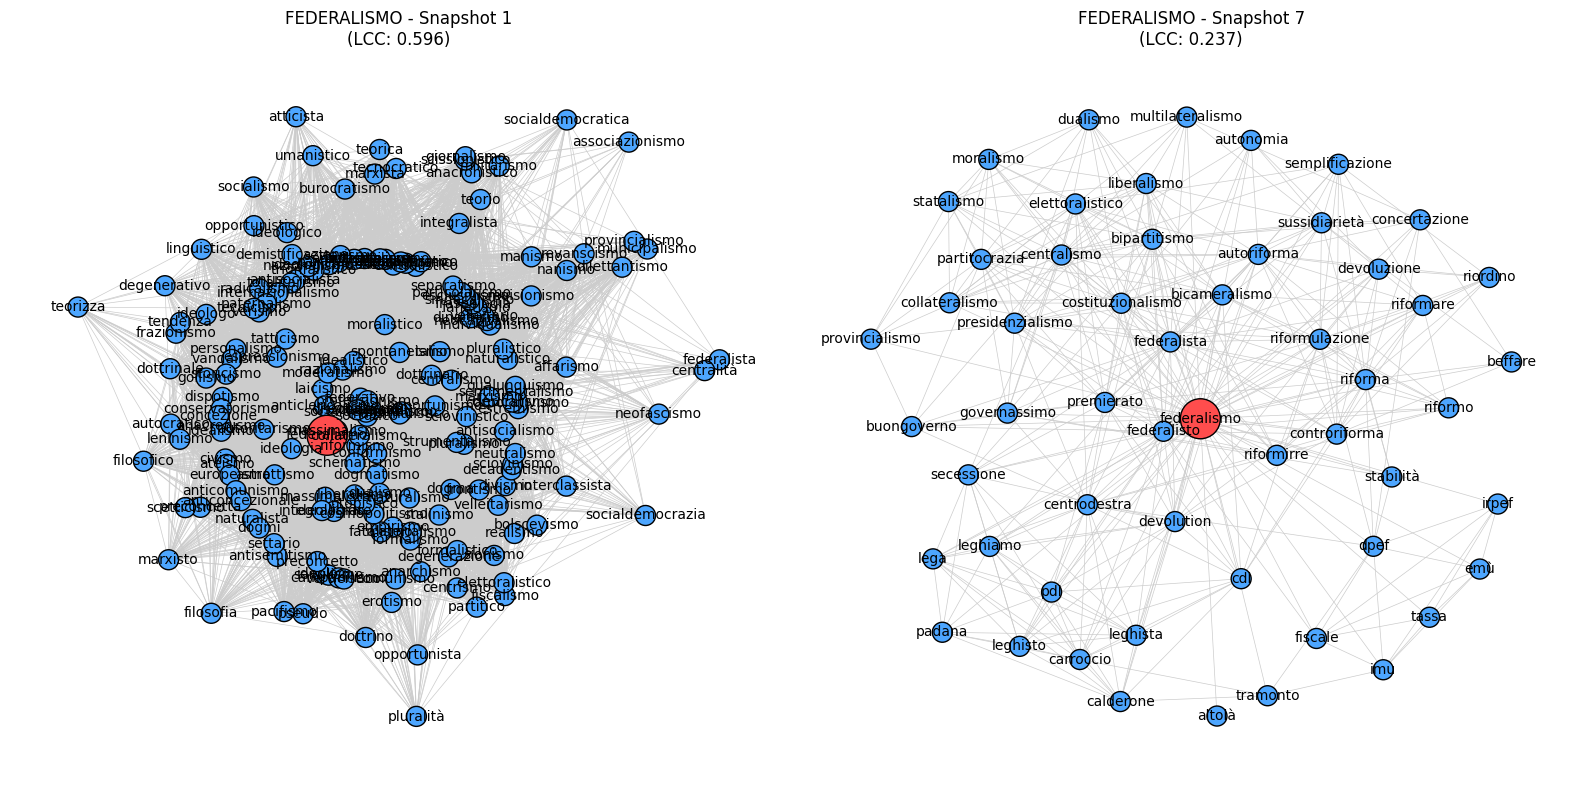

Generazione Ego Network per 'esibizione'...


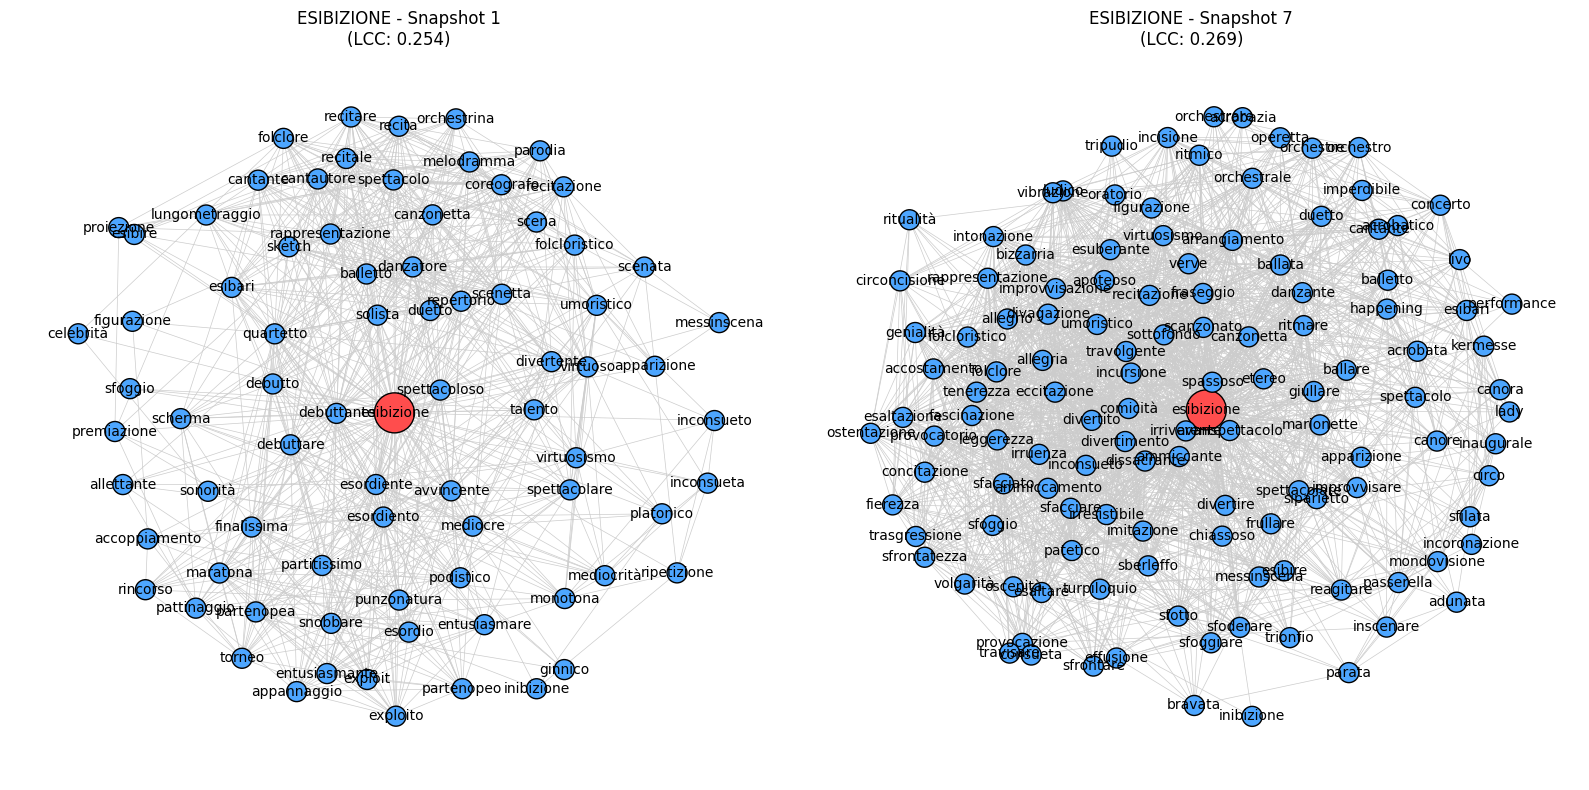

In [9]:
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np

def plot_ego_comparison(token, snap_start=1, snap_end=7):
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    snaps = [snap_start, snap_end]
    
    for i, snap in enumerate(snaps):
        file_path = f"networks_hybrid_annotated/graph_snap{snap}_hybrid.igp"
        g_full = ig.Graph.Read_Pickle(file_path)
        
        # 1. Ricalcolo LCC per sicurezza (evita il KeyError)
        g_full.vs["lcc"] = g_full.transitivity_local_undirected(mode="zero")
        
        # 2. Trova il nodo target
        try:
            # Cerchiamo prima in 'token', poi in 'name'
            if "token" in g_full.vs.attributes():
                target_node = g_full.vs.find(token=token)
            else:
                target_node = g_full.vs.find(name=token)
        except ValueError:
            print(f"Token '{token}' non trovato nello Snap {snap}")
            continue
            
        # 3. Estrai la Ego Network (vicini di primo grado)
        ego_indices = g_full.neighborhood(target_node, order=1)
        ego_graph = g_full.subgraph(ego_indices)
        
        # Prepara etichette e colori
        # Usiamo .get() o controlli diretti per evitare altri KeyError nelle etichette
        labels = [v["token"] if "token" in v.attributes() else v["name"] for v in ego_graph.vs]
        colors = ["#ff4d4d" if l == token else "#4da6ff" for l in labels]
        sizes = [40 if l == token else 20 for l in labels]
        
        # 4. Rendering del grafo
        # Nota: layout 'kk' (Kamada-Kawai) aiuta a vedere i raggruppamenti (clustering)
        layout = ego_graph.layout("kk")
        
        ig.plot(
            ego_graph,
            target=axs[i],
            layout=layout,
            vertex_size=sizes,
            vertex_color=colors,
            vertex_label=labels,
            vertex_label_size=10,
            edge_width=0.5,
            edge_color="#cccccc"
        )
        
        # Recuperiamo l'LCC dal nodo trovato
        current_lcc = target_node["lcc"]
        axs[i].set_title(f"{token.upper()} - Snapshot {snap}\n(LCC: {current_lcc:.3f})")

    plt.tight_layout()
    plt.show()

# Esecuzione
print("Generazione Ego Network per 'federalismo'...")
plot_ego_comparison("federalismo")

print("Generazione Ego Network per 'esibizione'...")
plot_ego_comparison("esibizione")

[START] Generazione Null Models (Configuration Model)
Snap 1 completato: Reale=0.3262, Null=0.0331
Snap 2 completato: Reale=0.3037, Null=0.0217
Snap 3 completato: Reale=0.2943, Null=0.0204
Snap 4 completato: Reale=0.2914, Null=0.0199
Snap 5 completato: Reale=0.2895, Null=0.0188
Snap 6 completato: Reale=0.2890, Null=0.0209
Snap 7 completato: Reale=0.2853, Null=0.0193


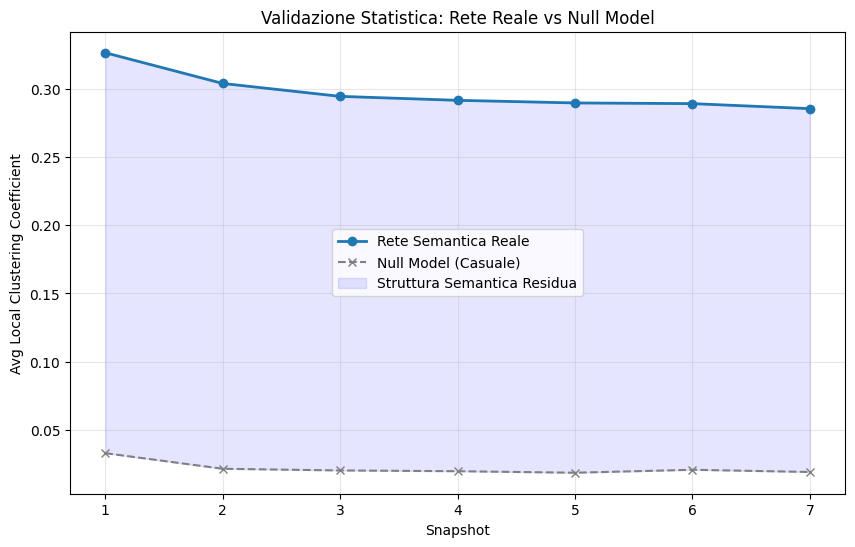


--- TABELLA DI VALIDAZIONE ---
   snapshot  LCC_Reale  LCC_Null  Differenza
0         1   0.326216  0.033087    0.293129
1         2   0.303725  0.021660    0.282065
2         3   0.294273  0.020430    0.273843
3         4   0.291370  0.019877    0.271494
4         5   0.289460  0.018766    0.270694
5         6   0.288958  0.020925    0.268032
6         7   0.285279  0.019307    0.265972


In [6]:
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

input_dir = Path("networks_hybrid_annotated")
null_comparison = []

print("[START] Generazione Null Models (Configuration Model)")

for snap in range(1, 8):
    file_path = input_dir / f"graph_snap{snap}_hybrid.igp"
    if not file_path.exists(): continue
    
    g_real = ig.Graph.Read_Pickle(str(file_path))
    
    # 1. Metrica Reale (Media globale)
    real_lcc_avg = np.mean(g_real.transitivity_local_undirected(mode="zero"))
    
    # 2. Generazione Null Model (metodo 'simple' per evitare errori di connessione)
    # Eseguiamo 10 iterazioni per avere una media più stabile
    null_lccs = []
    for i in range(10):
        # Crea un grafo casuale con la stessa sequenza di gradi del reale
        g_null = ig.Graph.Degree_Sequence(g_real.degree(), method="simple")
        null_lccs.append(np.mean(g_null.transitivity_local_undirected(mode="zero")))
    
    avg_null_lcc = np.mean(null_lccs)
    
    null_comparison.append({
        "snapshot": snap,
        "LCC_Reale": real_lcc_avg,
        "LCC_Null": avg_null_lcc,
        "Differenza": real_lcc_avg - avg_null_lcc
    })
    
    print(f"Snap {snap} completato: Reale={real_lcc_avg:.4f}, Null={avg_null_lcc:.4f}")

df_null = pd.DataFrame(null_comparison)

# --- VISUALIZZAZIONE PER LA TESI ---
plt.figure(figsize=(10, 6))
plt.plot(df_null['snapshot'], df_null['LCC_Reale'], label='Rete Semantica Reale', marker='o', linewidth=2)
plt.plot(df_null['snapshot'], df_null['LCC_Null'], label='Null Model (Casuale)', linestyle='--', marker='x', color='gray')
plt.fill_between(df_null['snapshot'], df_null['LCC_Null'], df_null['LCC_Reale'], color='blue', alpha=0.1, label='Struttura Semantica Residua')

plt.title("Validazione Statistica: Rete Reale vs Null Model")
plt.xlabel("Snapshot")
plt.ylabel("Avg Local Clustering Coefficient")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- TABELLA DI VALIDAZIONE ---")
print(df_null)

# TTR

In [ ]:
import os
import re

# Il tuo percorso specifico
CARTELLA_TARGET = r'../lemmas/snaps'

def calcola_ttr_progetto():
    # Verifica che la cartella esista
    if not os.path.exists(CARTELLA_TARGET):
        print(f"Errore: Il percorso {CARTELLA_TARGET} non è raggiungibile.")
        return

    # Intestazione tabella
    print(f"{'File':<15} | {'Tokens':<10} | {'Types':<10} | {'TTR':<8}")
    print("-" * 50)

    # Recupera tutti i file .txt che iniziano con 'snap' e ordinali
    files = [f for f in os.listdir(CARTELLA_TARGET) if f.startswith('snap') and f.endswith('.txt')]
    files.sort() # Li ordina (snap1, snap2, ecc.)

    for nome_file in files:
        path_completo = os.path.join(CARTELLA_TARGET, nome_file)
        
        try:
            with open(path_completo, 'r', encoding='utf-8') as f:
                testo = f.read().lower()
                
                # Pulizia: estrae solo le parole (esclude punteggiatura)
                parole = re.findall(r'\b\w+\b', testo)
                
                tokens = len(parole)
                types = len(set(parole))
                ttr = types / tokens if tokens > 0 else 0
                
                print(f"{nome_file:<15} | {tokens:<10} | {types:<10} | {ttr:.4f}")
                
        except Exception as e:
            print(f"{nome_file:<15} | Errore durante la lettura: {e}")

if __name__ == "__main__":
    calcola_ttr_progetto()

File            | Tokens     | Types      | TTR     
--------------------------------------------------
snap1.txt       | 61862643   | 370506     | 0.0060
snap2.txt       | 60076406   | 289884     | 0.0048
snap3.txt       | 58313663   | 292108     | 0.0050
snap4.txt       | 58889418   | 371271     | 0.0063
snap5.txt       | 58126501   | 402536     | 0.0069
snap6.txt       | 61470170   | 545006     | 0.0089
snap7.txt       | 58429590   | 404239     | 0.0069


In [ ]:
import os
import re

CARTELLA_TARGET = r'../lemmas/snaps'
FINESTRA_STTR = 10000  # Dimensione del blocco per la media

def calcola_sttr(parole, window_size):
    if len(parole) < window_size:
        return 0
    
    ttr_totale = 0
    num_blocchi = 0
    
    # Dividiamo la lista di parole in blocchi da 10.000
    for i in range(0, len(parole) - window_size + 1, window_size):
        blocco = parole[i : i + window_size]
        types = len(set(blocco))
        ttr_totale += (types / window_size)
        num_blocchi += 1
        
    return ttr_totale / num_blocchi if num_blocchi > 0 else 0

def analizza_corpus():
    if not os.path.exists(CARTELLA_TARGET):
        print("Percorso non trovato.")
        return

    print(f"{'File':<12} | {'Tokens':<10} | {'TTR':<8} | {'STTR (10k)':<10}")
    print("-" * 55)

    files = [f for f in os.listdir(CARTELLA_TARGET) if f.startswith('snap') and f.endswith('.txt')]
    files.sort()

    for nome_file in files:
        path = os.path.join(CARTELLA_TARGET, nome_file)
        try:
            with open(path, 'r', encoding='utf-8') as f:
                testo = f.read().lower()
                parole = re.findall(r'\b\w+\b', testo)
                
                tokens = len(parole)
                types = len(set(parole))
                
                ttr_semplice = types / tokens if tokens > 0 else 0
                sttr_val = calcola_sttr(parole, FINESTRA_STTR)
                
                print(f"{nome_file:<12} | {tokens:<10} | {ttr_semplice:.5f} | {sttr_val:.5f}")
                
        except Exception as e:
            print(f"{nome_file:<12} | Errore: {e}")

if __name__ == "__main__":
    analizza_corpus()

File         | Tokens     | TTR      | STTR (10k)
-------------------------------------------------------
snap1.txt    | 61862643   | 0.00599 | 0.26701
snap2.txt    | 60076406   | 0.00483 | 0.25150
snap3.txt    | 58313663   | 0.00501 | 0.25719
snap4.txt    | 58889418   | 0.00630 | 0.27866
snap5.txt    | 58126501   | 0.00693 | 0.28278
snap6.txt    | 61470170   | 0.00887 | 0.26950
snap7.txt    | 58429590   | 0.00692 | 0.26658


# RQ1 FINAL: Freq self and freq neigh

In [2]:
import igraph as ig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress

# =============================================================================
# 1. CONFIGURATION AND LOADING
# =============================================================================
input_dir = Path("networks_paradigmatic")
target_pos = ['NOUN', 'VERB', 'ADJ', 'ADV']
snapshots = range(1, 8)
x_time = np.array(list(snapshots))

def get_avg_neighbor_rel_freq(graph, node_index, total_tokens):
    """Calculates the average RPM of a node's neighbors."""
    neighbors = graph.neighbors(node_index)
    if not neighbors: return 0.0
    freqs = [graph.vs[ni]['freq'] for ni in neighbors if graph.vs[ni]['freq'] is not None]
    if not freqs: return 0.0
    return (np.mean(freqs) / total_tokens) * 1_000_000

print("--- 1. Loading Graphs and Identifying Persistent Core ---")
graphs = {}
total_tokens_map = {}

for snap in snapshots:
    path = input_dir / f"graph_snap{snap}_paradigmatic.igp"
    g = ig.Graph.Read_Pickle(str(path))
    graphs[snap] = g
    total_tokens_map[snap] = sum([f for f in g.vs['freq'] if f is not None])

core_nodes = set(graphs[1].vs['token'])
for snap in range(2, 8):
    core_nodes = core_nodes.intersection(set(graphs[snap].vs['token']))
core_nodes = list(core_nodes)
pos_map = {v['token']: v['pos'] for v in graphs[1].vs if v['token'] in core_nodes}

# =============================================================================
# 2. TRAJECTORY CALCULATION (SLOPES)
# =============================================================================
print("--- 2. Calculating Slopes ---")
data = []
for name in core_nodes:
    pos = pos_map.get(name, 'UNK')
    if pos not in target_pos: continue
    
    y_self = []
    y_neigh = []
    
    for snap in snapshots:
        g = graphs[snap]
        idx = g.vs.find(token=name).index
        total = total_tokens_map[snap]
        
        y_self.append(np.log10(((g.vs[idx]['freq'] / total) * 1_000_000) + 1))
        y_neigh.append(np.log10(get_avg_neighbor_rel_freq(g, idx, total) + 1))
    
    s_self, _, _, _, _ = linregress(x_time, y_self)
    s_neigh, _, _, _, _ = linregress(x_time, y_neigh)
    
    data.append({'token': name, 'pos': pos, 'slope_self': s_self, 'slope_neigh': s_neigh})

df = pd.DataFrame(data)

# =============================================================================
# 3. DESCRIPTIVE ANALYSIS: WINNERS VS OTHERS
# =============================================================================
print("\n" + "="*75)
print("RQ1: DESCRIPTIVE ANALYSIS - TOP 25% GROWTH (WINNERS)")
print("="*75)

# Assegnazione dei gruppi
df['Group'] = 'Rest of the Network'
summary_data = []

for pos in target_pos:
    subset = df[df['pos'] == pos]
    if subset.empty: continue
    
    threshold = subset['slope_self'].quantile(0.75)
    
    # Marcatura nel dataframe originale per il plot
    df.loc[(df['pos'] == pos) & (df['slope_self'] >= threshold), 'Group'] = 'Top 25% Growth (Winners)'
    
    winners = subset[subset['slope_self'] >= threshold]
    others = subset[subset['slope_self'] < threshold]
    
    summary_data.append({
        'POS': pos,
        'N_Winners': len(winners),
        'Avg_Slope_Self_Winners': round(winners['slope_self'].mean(), 6),
        'Avg_Slope_Neigh_Winners': round(winners['slope_neigh'].mean(), 6),
        'Avg_Slope_Neigh_Others': round(others['slope_neigh'].mean(), 6)
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


--- 1. Loading Graphs and Identifying Persistent Core ---
--- 2. Calculating Slopes ---

RQ1: DESCRIPTIVE ANALYSIS - TOP 25% GROWTH (WINNERS)
 POS  N_Winners  Avg_Slope_Self_Winners  Avg_Slope_Neigh_Winners  Avg_Slope_Neigh_Others
NOUN       1957                0.076307                 0.036758               -0.003666
VERB       1714                0.063398                 0.032820                0.005297
 ADJ        873                0.067163                 0.020269               -0.007229
 ADV        230                0.055284                 0.020009                0.008912


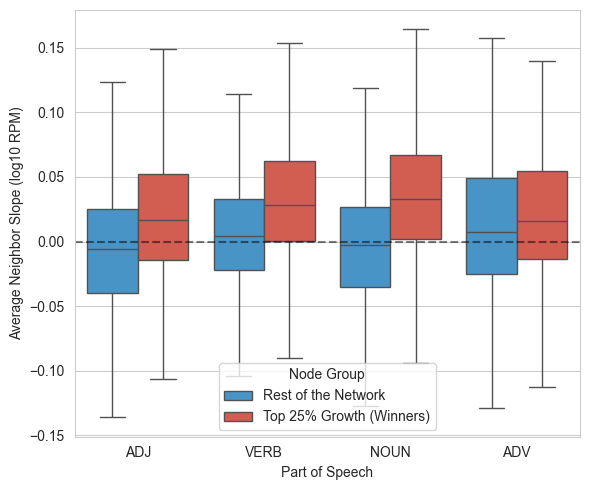

In [11]:

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
plt.figure(figsize=(6, 5))
sns.set_style("whitegrid")

# Boxplot
ax = sns.boxplot(data=df, x='pos', y='slope_neigh', hue='Group', 
                 palette={'Top 25% Growth (Winners)': '#e74c3c', 'Rest of the Network': '#3498db'},
                 showfliers=False)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
#plt.title("Neighbor Slopes Distribution: Winners (Top 25%) vs. Others")
plt.ylabel("Average Neighbor Slope (log10 RPM)")
plt.xlabel("Part of Speech")
plt.legend(title="Node Group")

plt.tight_layout()
plt.show()

In [2]:
# =============================================================================
#  QUALITATIVE INSPECTION: INSPECTING TOP 25% AND THEIR NEIGHBORS
# =============================================================================
print("\n" + "="*75)
print("INSPECTION: TOP WINNERS AND THEIR SEMANTIC NEIGHBORS (Final Snapshot)")
print("="*75)

last_snap = snapshots[-1]
g_final = graphs[last_snap]

# Numero di esempi da mostrare per ogni POS
n_examples = 5

for pos in target_pos:
    print(f"\n>>> Top Winners for POS: {pos} <<<")
    
    # Identifica la soglia del top 25% per questo POS
    subset = df[df['pos'] == pos]
    threshold = subset['slope_self'].quantile(0.75)
    
    # Prendi i top N "Winners" con la crescita (slope_self) più alta
    top_winners = subset[subset['slope_self'] >= threshold].sort_values(by='slope_self', ascending=False).head(n_examples)
    
    for _, row in top_winners.iterrows():
        token = row['token']
        slope = row['slope_self']
        
        # Trova i vicini nel grafo finale
        try:
            node_idx = g_final.vs.find(token=token).index
            # Otteniamo i vicini e li ordiniamo per peso dell'arco (se disponibile) o per frequenza
            neighbors_indices = g_final.neighbors(node_idx)
            
            # Recuperiamo i token dei vicini e le loro frequenze
            neighbor_data = []
            for ni in neighbors_indices:
                n_v = g_final.vs[ni]
                neighbor_data.append((n_v['token'], n_v['freq']))
            
            # Ordiniamo i vicini per frequenza decrescente per vedere chi sono i "compagni" principali
            neighbor_data = sorted(neighbor_data, key=lambda x: x[1] if x[1] is not None else 0, reverse=True)
            top_neighs = [f"{t}" for t, f in neighbor_data[:10]] # Primi 10 vicini
            
            print(f"- {token.upper()} (Slope: {slope:.4f})")
            print(f"  Top Neighbors: {', '.join(top_neighs)}")
            print("-" * 30)
            
        except ValueError:
            # Il nodo potrebbe non essere presente nell'ultimo snapshot (anche se nel core dovrebbe esserci)
            continue


INSPECTION: TOP WINNERS AND THEIR SEMANTIC NEIGHBORS (Final Snapshot)

>>> Top Winners for POS: NOUN <<<
- EURO (Slope: 0.3254)
  Top Neighbors: milione, miliardo, dollaro, cifra, somma, prestito, rimborso, lira, multa, assegno
------------------------------
- RIFONDAZIONE (Slope: 0.3118)
  Top Neighbors: partito, sinistra, unione, opposizione, centrosinistra, deputato, prodi, unitario, federazione, capogruppo
------------------------------
- CIAMPO (Slope: 0.3070)
  Top Neighbors: berluscone, repubblica, prodi, casine, mastella, schifaco, azeglio, ciampi, pera, sfore
------------------------------
- CASINE (Slope: 0.2833)
  Top Neighbors: berluscone, camera, senato, centrosinistra, silvio, prodi, renza, alleato, bersani, coltrone
------------------------------
- FORUM (Slope: 0.2639)
  Top Neighbors: conferenza, convegno, coordinamento, promotore, organizzatore, network, sessione, meeting, isp, promosso
------------------------------

>>> Top Winners for POS: VERB <<<
- BEFFARE (Slop

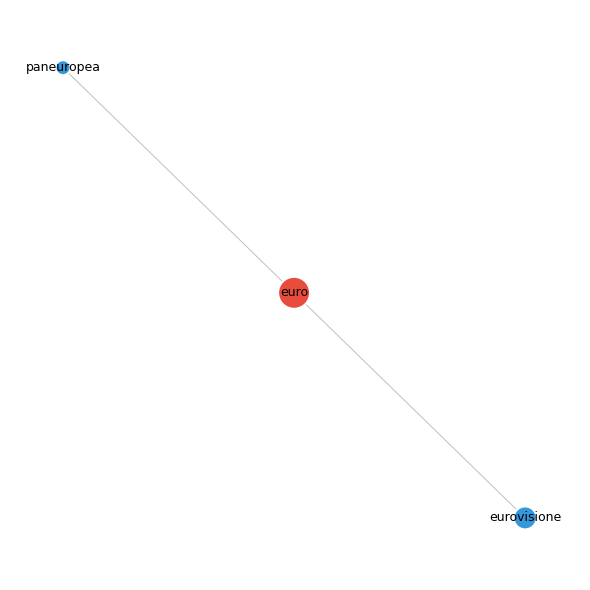

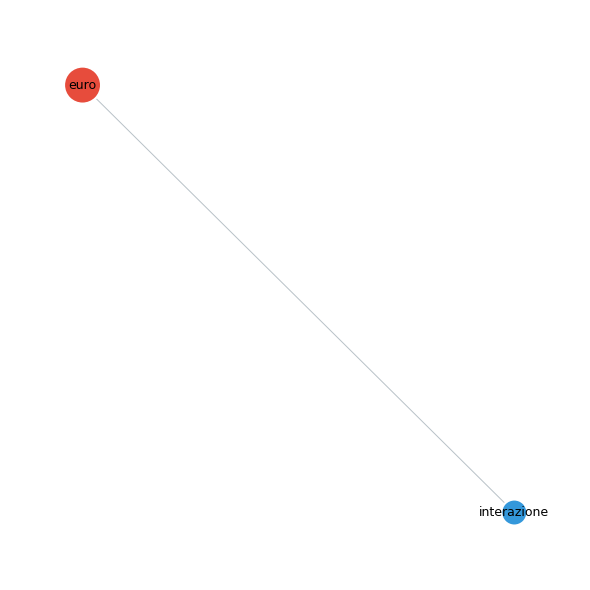

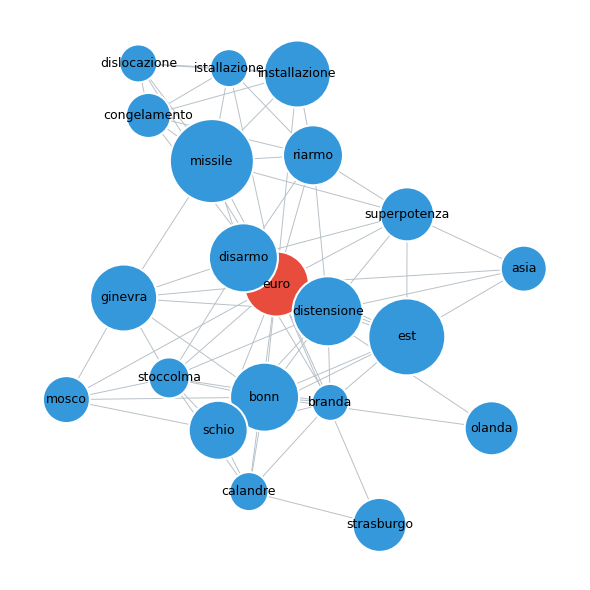

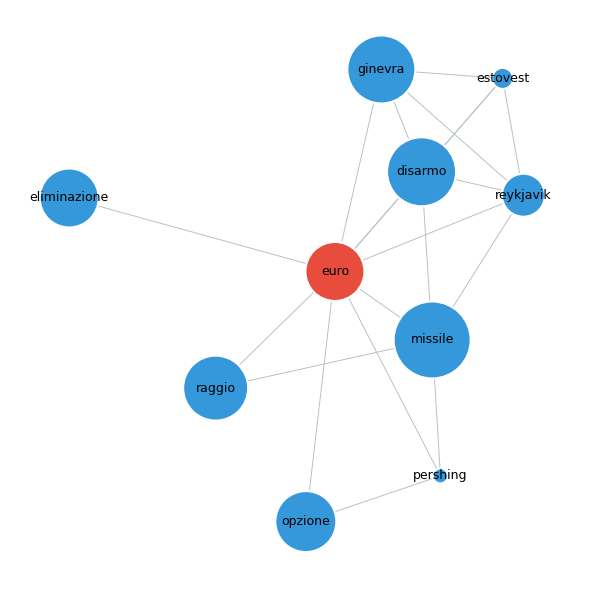

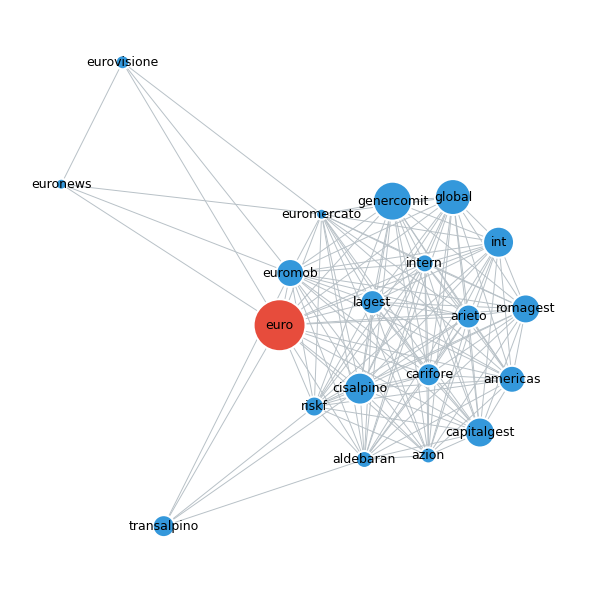

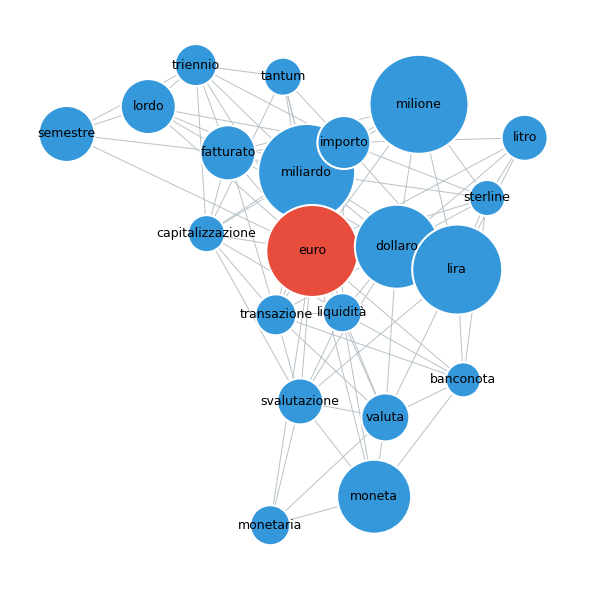

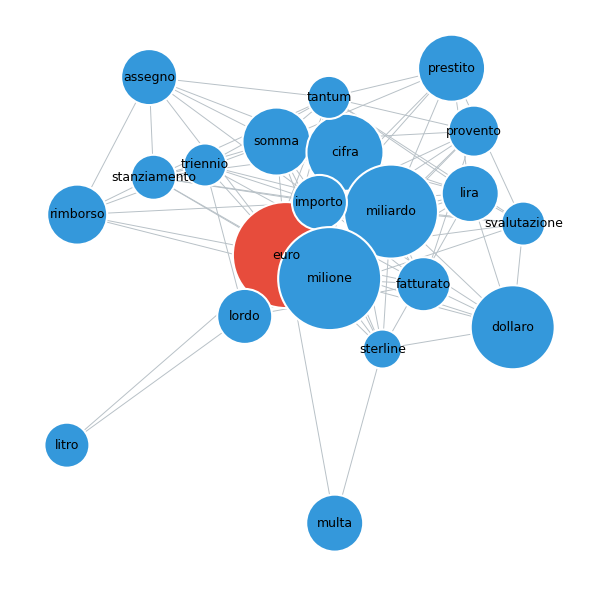

In [6]:
import matplotlib.pyplot as plt
def plot_ego_evolution_separate(target_token, graphs, snapshots, top_n=15):
    """
    Generates a separate figure for each snapshot of the token's ego network.
    Labels are placed directly on the nodes.
    """
    main_node_color = "#e74c3c"  # Red
    neighbor_color = "#3498db"   # Blue
    
    for snap in snapshots:
        g = graphs[snap]
        fig, ax = plt.subplots(figsize=(6, 6)) # Slightly larger for better label clarity
        
        try:
            # 1. Identify the central node and its top neighbors
            center_idx = g.vs.find(token=target_token).index
            all_neighbors = g.neighbors(center_idx)
            
            # Sort by frequency to keep only the most significant neighbors
            sorted_neighs = sorted(all_neighbors, 
                                   key=lambda x: g.vs[x]['freq'] if g.vs[x]['freq'] else 0, 
                                   reverse=True)
            top_neighbors = sorted_neighs[:top_n]
            
            # Create subgraph
            subgraph_indices = [center_idx] + top_neighbors
            ego_net = g.subgraph(subgraph_indices)
            
            # 2. Layout and Styling
            layout = ego_net.layout_fruchterman_reingold(niter=500)
            labels = ego_net.vs['token']
            colors = [main_node_color if t == target_token else neighbor_color for t in labels]
            
            # 3. Size scaling (increased for label containment)
            total_tokens = sum([f for f in g.vs['freq'] if f is not None])
            def get_size(v):
                rpm = (v['freq'] / total_tokens) * 1_000_000
                # Increased multiplier to make nodes large enough to hold text
                return np.log10(rpm + 1) * 35 

            sizes = [get_size(v) for v in ego_net.vs]
            
            # 4. Plotting
            ig.plot(
                ego_net,
                target=ax,
                layout=layout,
                vertex_size=sizes,
                vertex_color=colors,
                vertex_label=labels,
                vertex_label_size=9,
                vertex_label_dist=0,      # <--- Key change: 0 places label on node
                vertex_label_color="black", # Better contrast for blue/red nodes
                vertex_frame_width=1.5,
                vertex_frame_color="white",
                edge_width=0.7,
                edge_color="#b8c1c7"
            )
            
            #plt.title(f"Ego Network: {target_token.upper()} | Snapshot {snap}", pad=20)
            ax.axis('off')
            plt.tight_layout()
            plt.show()

        except ValueError:
            print(f"Token '{target_token}' not found in Snapshot {snap}.")
            plt.close(fig)

# --- EXECUTION ---
plot_ego_evolution_separate("euro", graphs, snapshots, top_n=20)

--- 3. Generating Scatter Plots with Regression Lines ---


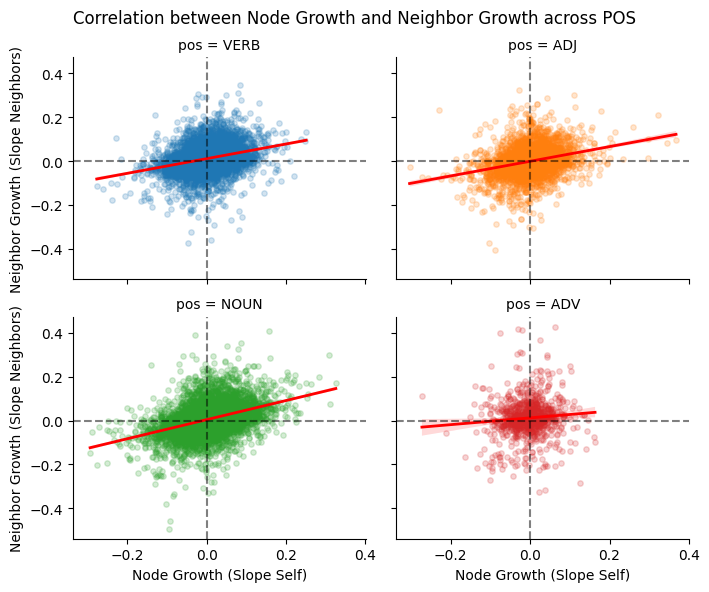

In [ ]:

print("--- 3. Generating Scatter Plots with Regression Lines ---")

# We use FacetGrid to create one plot per POS
g = sns.lmplot(
    data=df, 
    x='slope_self', 
    y='slope_neigh', 
    col='pos', 
    hue='pos',
    col_wrap=2, 
    height=3, 
    aspect=1.2,
    scatter_kws={'alpha': 0.2, 's': 15}, # transparency to see density
    line_kws={'color': 'red', 'lw': 2}   # clear red regression line
)

# Add reference lines for the "Zero" point
for ax in g.axes.flatten():
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel("Node Growth (Slope Self)")
    ax.set_ylabel("Neighbor Growth (Slope Neighbors)")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Correlation between Node Growth and Neighbor Growth across POS')

plt.show()

--- DISTRIBUZIONE PERCENTUALE DEI NODI NEI QUADRANTI ---
Quadrant Lose-Lose (Domain Decline) Lose-Win (Substitution)  \
pos                                                           
ADJ                          29.83%                  19.71%   
ADV                          24.29%                  28.87%   
NOUN                         28.01%                  17.76%   
VERB                         25.36%                   23.9%   

Quadrant Win-Lose (Impoverishment) Win-Win (Co-expansion)  
pos                                                        
ADJ                         20.86%                  29.6%  
ADV                         16.67%                 30.17%  
NOUN                        17.63%                  36.6%  
VERB                        14.74%                  36.0%  

--- FOCUS SULLE PAROLE IN CRESCITA (Slope Self > 0) ---
Tra le parole che crescono, quante trascinano i vicini (Win-Win) e quante li affossano (Win-Lose)?
Quadrant Win-Win (Co-expansion) Win-Lose (Impove

<Figure size 1000x600 with 0 Axes>

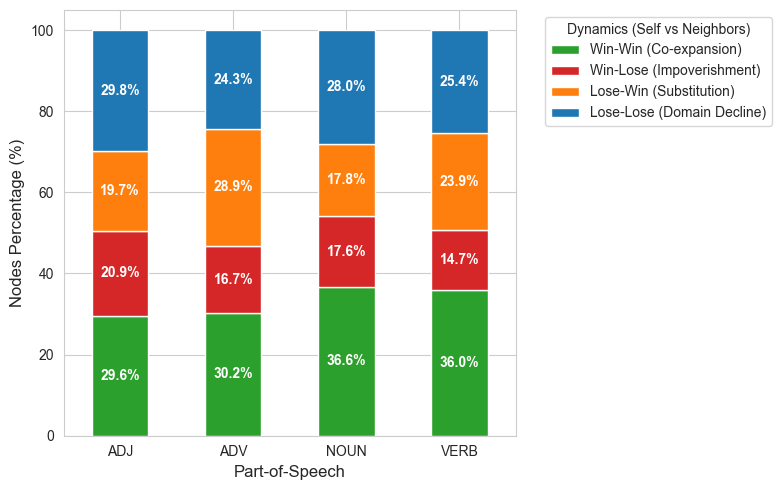

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# 1. CLASSIFICAZIONE NEI 4 QUADRANTI
# =============================================================================

def classify_quadrant(row):
    s_self = row['slope_self']
    s_neigh = row['slope_neigh']
    
    if s_self > 0 and s_neigh > 0:
        return 'Win-Win (Co-expansion)'
    elif s_self > 0 and s_neigh < 0:
        return 'Win-Lose (Impoverishment)'
    elif s_self < 0 and s_neigh > 0:
        return 'Lose-Win (Substitution)'
    elif s_self < 0 and s_neigh < 0:
        return 'Lose-Lose (Domain Decline)'
    else:
        return 'Neutral / Zero'

# Applichiamo la classificazione
df['Quadrant'] = df.apply(classify_quadrant, axis=1)

# Rimuoviamo eventuali nodi esattamente a zero (molto rari con le regressioni)
df_valid = df[df['Quadrant'] != 'Neutral / Zero']

# =============================================================================
# 2. CALCOLO PERCENTUALI E TABELLA
# =============================================================================

# Calcoliamo i conteggi per POS e Quadrante
counts = df_valid.groupby(['pos', 'Quadrant']).size().unstack(fill_value=0)

# Convertiamo in percentuali (riga per riga)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

print("--- DISTRIBUZIONE PERCENTUALE DEI NODI NEI QUADRANTI ---")
print(percentages.round(2).astype(str) + '%')

# Se vuoi isolare solo la dicotomia per i "Dominant Expanders" (chi ha Slope Self > 0):
df_growing = df_valid[df_valid['slope_self'] > 0]
grow_counts = df_growing.groupby(['pos', 'Quadrant']).size().unstack(fill_value=0)
grow_pct = grow_counts.div(grow_counts.sum(axis=1), axis=0) * 100

print("\n--- FOCUS SULLE PAROLE IN CRESCITA (Slope Self > 0) ---")
print("Tra le parole che crescono, quante trascinano i vicini (Win-Win) e quante li affossano (Win-Lose)?")
print(grow_pct[['Win-Win (Co-expansion)', 'Win-Lose (Impoverishment)']].round(2).astype(str) + '%')

# =============================================================================
# 3. VISUALIZZAZIONE
# =============================================================================

plt.figure(figsize=(10, 6))

# Colori per i 4 quadranti
colors = {
    'Win-Win (Co-expansion)': '#2ca02c',       # Verde
    'Win-Lose (Impoverishment)': '#d62728',    # Rosso
    'Lose-Win (Substitution)': '#ff7f0e',      # Arancione
    'Lose-Lose (Domain Decline)': '#1f77b4'    # Blu
}

# Ordiniamo le colonne per averle fisse nel plot
cols_order = ['Win-Win (Co-expansion)', 'Win-Lose (Impoverishment)', 
              'Lose-Win (Substitution)', 'Lose-Lose (Domain Decline)']
percentages = percentages.reindex(columns=cols_order)

# Plot stacked bar chart
ax = percentages.plot(kind='bar', stacked=True, color=[colors[c] for c in cols_order], 
                      figsize=(8, 5), edgecolor='white')

#plt.title('Proporzione delle Dinamiche Strutturali per POS', fontsize=14)
plt.ylabel('Nodes Percentage (%)', fontsize=12)
plt.xlabel('Part-of-Speech', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Dynamics (Self vs Neighbors)', bbox_to_anchor=(1.05, 1), loc='upper left')

# Aggiunta delle percentuali al centro di ogni blocco
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Mostra il testo solo se il blocco è più grande del 5% per leggibilità
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# NUll model

In [4]:
# =============================================================================
# 6. NULL MODEL: CO-EXPANSION SIGNIFICANCE (Synergy vs Random)
# =============================================================================
from scipy.stats import norm

print("\n" + "="*75)
print("NULL MODEL: TESTING CO-EXPANSION (Winners' Neighbors Growth vs Random)")
print("="*75)

n_permutations = 1000
null_model_results = []

for pos in target_pos:
    subset = df[df['pos'] == pos].copy()
    if subset.empty: continue
    
    # 1. VALORE OSSERVATO
    # Identifichiamo i Winners (Top 25%) e i loro vicini reali
    threshold = subset['slope_self'].quantile(0.75)
    winners_mask = subset['slope_self'] >= threshold
    
    # La nostra metrica: quanto crescono i vicini dei winners rispetto agli altri?
    observed_diff = subset[winners_mask]['slope_neigh'].mean() - subset[~winners_mask]['slope_neigh'].mean()
    
    # 2. GENERAZIONE DISTRIBUZIONE NULLA (Rete Random)
    # Rimescoliamo le pendenze dei vicini per simulare una rete in cui 
    # i legami tra parole sono casuali e non riflettono relazioni semantiche.
    null_diffs = []
    all_neigh_slopes = subset['slope_neigh'].values
    n_winners = winners_mask.sum()
    
    for _ in range(n_permutations):
        shuffled = np.random.permutation(all_neigh_slopes)
        # Differenza media in una configurazione di rete random
        null_diff = np.mean(shuffled[:n_winners]) - np.mean(shuffled[n_winners:])
        null_diffs.append(null_diff)
    
    # 3. STATISTICHE (Z-Test)
    null_mean = np.mean(null_diffs)
    null_std = np.std(null_diffs)
    
    # Z-score positivo = la co-espansione è più forte che nel caso random
    z_score = (observed_diff - null_mean) / null_std if null_std > 0 else 0
    
    # P-value (one-tailed): probabilità che la sinergia sia casuale
    # Cerchiamo P < 0.05 per confermare che i vicini "spingono" insieme al Winner
    p_val_z = 1 - norm.cdf(z_score) 
    
    null_model_results.append({
        'POS': pos,
        'Obs_Diff (Sinergia)': round(observed_diff, 6),
        'Z-Score (Strength)': round(z_score, 4),
        'P-value (Signific.)': round(p_val_z, 10),
        'Status': 'SIGNIFICANT' if p_val_z < 0.05 else 'Random'
    })

df_null = pd.DataFrame(null_model_results)
print(df_null.to_string(index=False))


NULL MODEL: TESTING CO-EXPANSION (Winners' Neighbors Growth vs Random)
 POS  Obs_Diff (Sinergia)  Z-Score (Strength)  P-value (Signific.)      Status
NOUN             0.040425             23.2676             0.000000 SIGNIFICANT
VERB             0.027523             18.0000             0.000000 SIGNIFICANT
 ADJ             0.027498             10.6540             0.000000 SIGNIFICANT
 ADV             0.011097              1.6659             0.047864 SIGNIFICANT


In [ ]:

print("\n" + "="*75)
print("NULL MODEL 1: NEIGHBORHOOD RESAMPLING (Is the synergy specific?)")
print("="*75)

n_resamples = 1000
resampling_results = []

for pos in target_pos:
    subset = df[df['pos'] == pos].copy()
    if subset.empty: continue
    
    # 1. Identifichiamo i Winners reali
    threshold = subset['slope_self'].quantile(0.75)
    winners_df = subset[subset['slope_self'] >= threshold]
    
    # Valore osservato: la crescita media dei vicini reali dei winners
    observed_neigh_growth = winners_df['slope_neigh'].mean()
    
    # 2. Pool di "potenziali vicini" (tutte le slope della stessa POS)
    all_possible_slopes = subset['slope_self'].values
    
    null_means = []
    for _ in range(n_resamples):
        # Simuliamo nuovi vicini per ogni winner estraendo a caso dal pool
        # Questo mantiene il numero di winners ma cambia 'chi' sono i loro vicini
        fake_samples = np.random.choice(all_possible_slopes, size=len(winners_df), replace=True)
        null_means.append(np.mean(fake_samples))
    
 
    
    # 3. Statistiche Avanzate
    null_means = np.array(null_means)
    null_mean_val = np.mean(null_means)
    null_std_val = np.std(null_means)
    
    # Z-score
    z_score_topo = (observed_neigh_growth - null_mean_val) / null_std_val if null_std_val > 0 else 0
    
    # P-value Empirico: proporzione di casi random >= osservato
    # Aggiungiamo +1 al numeratore e denominatore per evitare p-value pari a 0 (correzione di Davison-Hinkley)
    p_val_empirico = (np.sum(null_means >= observed_neigh_growth) + 1) / (n_resamples + 1)

    resampling_results.append({
        'POS': pos,
        'Obs_Growth': observed_neigh_growth,
        'Exp_Growth': null_mean_val,
        'Z-Score': z_score_topo,
        'P-value': p_val_empirico
    })

# --- VISUALIZZAZIONE OTTIMIZZATA ---
df_resampling = pd.DataFrame(resampling_results)

# Formattazione: usiamo la notazione scientifica per il p-value e 6 decimali per gli altri
formatters = {
    'Obs_Growth': '{:.6f}'.format,
    'Exp_Growth': '{:.6f}'.format,
    'Z-Score': '{:.4f}'.format,
    'P-value': '{:.4e}'.format  # Notazione scientifica per vedere tutte le cifre
}

print(df_resampling.to_string(index=False, formatters=formatters))


NULL MODEL 2: NEIGHBORHOOD RESAMPLING (Is the synergy specific?)
 POS Obs_Growth Exp_Growth Z-Score    P-value
NOUN   0.036758   0.004832 24.8021 9.9900e-04
VERB   0.032820   0.001644 25.9484 9.9900e-04
 ADJ   0.020269   0.000025 10.9237 9.9900e-04
 ADV   0.020009  -0.004843  7.7014 9.9900e-04


In [1]:
import igraph as ig
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import linregress
import random

# Impostazione seed per riproducibilità
random.seed(42)
np.random.seed(42)

# =============================================================================
# 1. CONFIGURATION AND LOADING
# =============================================================================
input_dir = Path("networks_paradigmatic")
target_pos = ['NOUN', 'VERB', 'ADJ', 'ADV']
snapshots = range(1, 8)
x_time = np.array(list(snapshots))

# --- OTTIMIZZAZIONE MATEMATICA PER VELOCIZZARE IL NULL MODEL ---
# Dato che X (il tempo) è sempre [1, 2, 3, 4, 5, 6, 7], possiamo calcolare la slope 
# in modo istantaneo tramite prodotto scalare, saltando la lenta funzione linregress().
x_mean = np.mean(x_time)
x_dev = x_time - x_mean
S_xx = np.sum(x_dev**2)

def fast_slope(y_array):
    """Calcola la regressione lineare in frazioni di millisecondo"""
    y_mean = np.mean(y_array)
    return np.dot(x_dev, y_array - y_mean) / S_xx

def get_avg_neighbor_rel_freq(graph, node_index, total_tokens):
    neighbors = graph.neighbors(node_index)
    if not neighbors: return 0.0
    freqs = [graph.vs[ni]['freq'] for ni in neighbors if graph.vs[ni]['freq'] is not None]
    if not freqs: return 0.0
    return (np.mean(freqs) / total_tokens) * 1_000_000

print("--- 1. Loading Graphs and Identifying Persistent Core ---")
graphs = {}
total_tokens_map = {}

for snap in snapshots:
    path = input_dir / f"graph_snap{snap}_paradigmatic.igp"
    g = ig.Graph.Read_Pickle(str(path))
    graphs[snap] = g
    total_tokens_map[snap] = sum([f for f in g.vs['freq'] if f is not None])

core_nodes = set(graphs[1].vs['token'])
for snap in range(2, 8):
    core_nodes = core_nodes.intersection(set(graphs[snap].vs['token']))
core_nodes = list(core_nodes)
pos_map = {v['token']: v['pos'] for v in graphs[1].vs if v['token'] in core_nodes}

# =============================================================================
# 2. TRAJECTORY CALCULATION & DATA STORAGE
# =============================================================================
print("--- 2. Calculating Slopes and Storing Time Series ---")
data = []

# Ora salviamo entrambe le storie per ricalcolare TUTTO nel Null Model
y_self_history = {} 
y_neigh_history = {} 

for name in core_nodes:
    pos = pos_map.get(name, 'UNK')
    if pos not in target_pos: continue
    
    y_self = []
    y_neigh = []
    
    for snap in snapshots:
        g = graphs[snap]
        idx = g.vs.find(token=name).index
        total = total_tokens_map[snap]
        
        y_self.append(np.log10(((g.vs[idx]['freq'] / total) * 1_000_000) + 1))
        y_neigh.append(np.log10(get_avg_neighbor_rel_freq(g, idx, total) + 1))
    
    # Salvataggio matrici come numpy array per velocità
    y_self_history[name] = np.array(y_self)
    y_neigh_history[name] = np.array(y_neigh)
    
    # Calcolo Slope empiriche
    s_self = fast_slope(y_self_history[name])
    s_neigh = fast_slope(y_neigh_history[name])
    
    data.append({'token': name, 'pos': pos, 'slope_self': s_self, 'slope_neigh': s_neigh})

df = pd.DataFrame(data)

# =============================================================================
# 3. NULL MODEL 2: ADVANCED TEMPORAL SHUFFLE
# =============================================================================
print("\n--- 3. Running Null Model 2: Advanced Temporal Shuffle ---")

# A. Prepariamo i valori OSSERVATI (Empirici)
obs_mean_slopes = {}
for pos in target_pos:
    subset = df[df['pos'] == pos]
    if subset.empty: continue
    threshold = subset['slope_self'].quantile(0.75)
    winners = subset[subset['slope_self'] >= threshold]
    obs_mean_slopes[pos] = winners['slope_neigh'].mean()

# B. Esecuzione Permutazioni
n_iterations = 1000 
null_distributions = {pos: [] for pos in target_pos}

# Isoliamo i nodi validi per non ciclare su roba inutile
valid_nodes = [n for n in core_nodes if pos_map.get(n, 'UNK') in target_pos]

for i in range(n_iterations):
    if i % 100 == 0:
        print(f" Iterazione {i}/{n_iterations}...")
        
    # Creiamo una singola permutazione globale del tempo (mantiene la topologia coerente al tempo T)
    idx_perm = np.random.permutation(len(snapshots))
    
    # Dizionario temporaneo per le slope di questo universo casuale
    temp_slopes = {pos: {'self': [], 'neigh': []} for pos in target_pos}
    
    # Calcoliamo le nuove slope per TUTTI i nodi nel nuovo ordine temporale
    for name in valid_nodes:
        pos = pos_map[name]
        
        shuffled_y_self = y_self_history[name][idx_perm]
        shuffled_y_neigh = y_neigh_history[name][idx_perm]
        
        s_self_shuff = fast_slope(shuffled_y_self)
        s_neigh_shuff = fast_slope(shuffled_y_neigh)
        
        temp_slopes[pos]['self'].append(s_self_shuff)
        temp_slopes[pos]['neigh'].append(s_neigh_shuff)
        
    # Troviamo i "Falsi Dominant Expanders" (Nuova Top 25%) per questo universo
    for pos in target_pos:
        if not temp_slopes[pos]['self']: continue
        
        self_arr = np.array(temp_slopes[pos]['self'])
        neigh_arr = np.array(temp_slopes[pos]['neigh'])
        
        threshold_shuff = np.quantile(self_arr, 0.75)
        
        # Maschera booleana: chi sono i nuovi vincitori?
        new_winners_mask = self_arr >= threshold_shuff
        
        # Qual è la media dei loro vicini?
        mean_neigh_shuff = np.mean(neigh_arr[new_winners_mask])
        null_distributions[pos].append(mean_neigh_shuff)

# C. Calcolo delle Statistiche Finali
results_nm = []
for pos in target_pos:
    if pos not in obs_mean_slopes: continue
    
    obs_val = obs_mean_slopes[pos]
    null_arr = np.array(null_distributions[pos])
    
    mean_null = np.mean(null_arr)
    std_null = np.std(null_arr)
    
    z_score = (obs_val - mean_null) / std_null if std_null != 0 else 0
    p_val_emp = (np.sum(null_arr >= obs_val) + 1) / (n_iterations + 1)
    
    sig = "***" if p_val_emp < 0.001 else "**" if p_val_emp < 0.01 else "*" if p_val_emp < 0.05 else "ns"
    
    results_nm.append({
        'POS': pos,
        'Obs_Mean_Slope': obs_val,
        'Exp_Mean_Null': mean_null,
        'Z-Score': z_score,
        'P-value': p_val_emp,
        'Sig.': sig
    })

df_res_nm = pd.DataFrame(results_nm)

formatters = {
    'Obs_Mean_Slope': '{:.5f}'.format,
    'Exp_Mean_Null': '{:.5f}'.format,
    'Z-Score': '{:.3f}'.format,
    'P-value': '{:.4e}'.format
}

print("\n--- RESULTS: TEMPORAL ROBUSTNESS (NEW LOGIC) ---")
print(df_res_nm.to_string(index=False, formatters=formatters))

--- 1. Loading Graphs and Identifying Persistent Core ---
--- 2. Calculating Slopes and Storing Time Series ---

--- 3. Running Null Model 2: Advanced Temporal Shuffle ---
 Iterazione 0/1000...
 Iterazione 100/1000...
 Iterazione 200/1000...
 Iterazione 300/1000...
 Iterazione 400/1000...
 Iterazione 500/1000...
 Iterazione 600/1000...
 Iterazione 700/1000...
 Iterazione 800/1000...
 Iterazione 900/1000...

--- RESULTS: TEMPORAL ROBUSTNESS (NEW LOGIC) ---
 POS Obs_Mean_Slope Exp_Mean_Null Z-Score    P-value Sig.
NOUN        0.03676       0.01641   1.968 9.9900e-03   **
VERB        0.03282       0.00892   2.398 3.9960e-03   **
 ADJ        0.02027       0.01242   0.836 2.1778e-01   ns
 ADV        0.02001       0.00418   1.069 1.6883e-01   ns


In [3]:
import numpy as np
import pandas as pd

print("\n" + "="*75)
print("NULL MODEL 1 (ALTERNATIVE): TOPOLOGICAL FEATURE SHUFFLING (Node Attribute Permutation)")
print("="*75)

# 1. COSTRUZIONE DELLA TOPOLOGIA DI RIFERIMENTO
# Poiché i collegamenti possono variare nei 7 snapshot, creiamo un'adiacenza globale
# unendo tutti i vicini che un nodo ha avuto nel corso del tempo (Union Graph).
core_adj = {node: set() for node in df['token']}

for snap in snapshots:
    g = graphs[snap]
    for v in g.vs:
        name = v['token']
        if name in core_adj:
            neighbors_idx = g.neighbors(v.index)
            # Troviamo i token dei vicini
            neighbors_names = [g.vs[ni]['token'] for ni in neighbors_idx]
            # Filtriamo tenendo solo i vicini che fanno parte del nostro set di analisi
            valid_neighbors = [nn for nn in neighbors_names if nn in core_adj]
            core_adj[name].update(valid_neighbors)

n_resamples = 1000
resampling_results = []

for pos in target_pos:
    subset = df[df['pos'] == pos].copy()
    if subset.empty: continue
    
    tokens = subset['token'].values
    actual_slopes = subset['slope_self'].values
    
    # Creiamo un dizionario per mappare rapidamente ogni token al suo indice (0...N) nell'array
    token_to_idx = {tok: i for i, tok in enumerate(tokens)}
    
    # Costruiamo la lista di adiacenza basata sugli indici per la massima velocità
    adj_idx = []
    for tok in tokens:
        # Recuperiamo gli indici dei vicini per questo specifico POS
        neigh_indices = [token_to_idx[n] for n in core_adj[tok] if n in token_to_idx]
        adj_idx.append(neigh_indices)
        
    # --- CALCOLO VALORE EMPIRICO (OSSERVATO) ---
    emp_threshold = np.quantile(actual_slopes, 0.75)
    emp_winners_idx = np.where(actual_slopes >= emp_threshold)[0]
    
    # Sfruttiamo la linearità: la slope della media dei vicini equivale alla media delle slope dei vicini
    emp_neigh_slopes = []
    for w_idx in emp_winners_idx:
        if len(adj_idx[w_idx]) > 0:
            emp_neigh_slopes.append(np.mean(actual_slopes[adj_idx[w_idx]]))
            
    observed_neigh_growth = np.mean(emp_neigh_slopes) if emp_neigh_slopes else 0
    
    # --- 2. ESECUZIONE DEL NULL MODEL (FEATURE SHUFFLING) ---
    null_means = []
    for _ in range(n_resamples):
        # Mescoliamo casualmente le traiettorie di crescita sull'intera rete
        shuffled_slopes = np.random.permutation(actual_slopes)
        
        # Identifichiamo i "Falsi Vincitori" in questo universo casuale
        shuff_threshold = np.quantile(shuffled_slopes, 0.75)
        fake_winners_idx = np.where(shuffled_slopes >= shuff_threshold)[0]
        
        # Calcoliamo come stanno i LORO veri vicini topologici (usando le slope mescolate)
        fake_neigh_slopes = []
        for w_idx in fake_winners_idx:
            neighbors = adj_idx[w_idx]
            if len(neighbors) > 0:
                fake_neigh_slopes.append(np.mean(shuffled_slopes[neighbors]))
        
        null_means.append(np.mean(fake_neigh_slopes) if fake_neigh_slopes else 0)
    
    # --- 3. STATISTICHE FINALI ---
    null_means = np.array(null_means)
    null_mean_val = np.mean(null_means)
    null_std_val = np.std(null_means)
    
    # Z-score
    z_score_topo = (observed_neigh_growth - null_mean_val) / null_std_val if null_std_val > 0 else 0
    
    # P-value Empirico (Correzione di Davison-Hinkley)
    p_val_empirico = (np.sum(null_means >= observed_neigh_growth) + 1) / (n_resamples + 1)
    
    sig = "***" if p_val_empirico < 0.001 else "**" if p_val_empirico < 0.01 else "*" if p_val_empirico < 0.05 else "ns"

    resampling_results.append({
        'POS': pos,
        'Obs_Growth': observed_neigh_growth,
        'Exp_Growth': null_mean_val,
        'Z-Score': z_score_topo,
        'P-value': p_val_empirico,
        'Sig.': sig
    })

# --- VISUALIZZAZIONE ---
df_resampling = pd.DataFrame(resampling_results)

formatters = {
    'Obs_Growth': '{:.6f}'.format,
    'Exp_Growth': '{:.6f}'.format,
    'Z-Score': '{:.4f}'.format,
    'P-value': '{:.4e}'.format
}

print(df_resampling.to_string(index=False, formatters=formatters))


NULL MODEL 1 (ALTERNATIVE): TOPOLOGICAL FEATURE SHUFFLING (Node Attribute Permutation)
 POS Obs_Growth Exp_Growth Z-Score    P-value Sig.
NOUN   0.016997   0.004854 30.1099 9.9900e-04  ***
VERB   0.013926   0.001664 31.9160 9.9900e-04  ***
 ADJ   0.011311   0.000004 19.4380 9.9900e-04  ***
 ADV   0.005504  -0.004847  8.1017 9.9900e-04  ***


--- 1. Caricamento Grafi e Core Nucleus ---
--- 2. Calcolo Pendenze Reali ---

--- 3. Esecuzione Null Model & Validazione (Z-Test) ---

VALIDAZIONE PER NOUN:
  - x_bar (Observed): 0.036758
  - mu (Null Mean):   -0.000028
  - sigma (Null Std): 0.001120
  - Z-SCORE:          32.8569


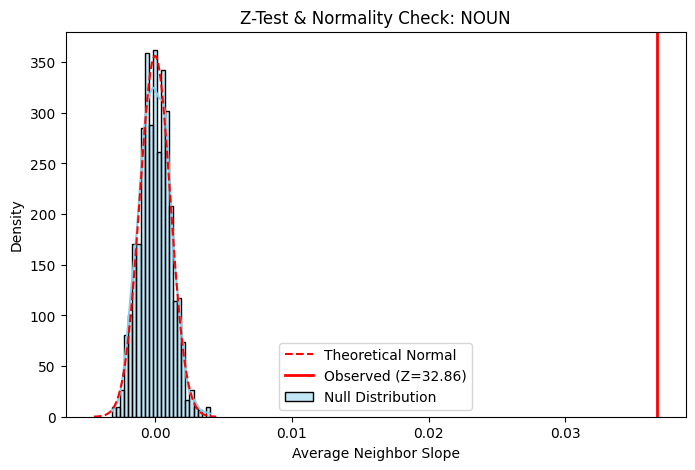

  - Shapiro-Wilk p-value: 0.0654 (Se > 0.05 è una campana perfetta)

VALIDAZIONE PER VERB:
  - x_bar (Observed): 0.032820
  - mu (Null Mean):   0.000032
  - sigma (Null Std): 0.001110
  - Z-SCORE:          29.5447


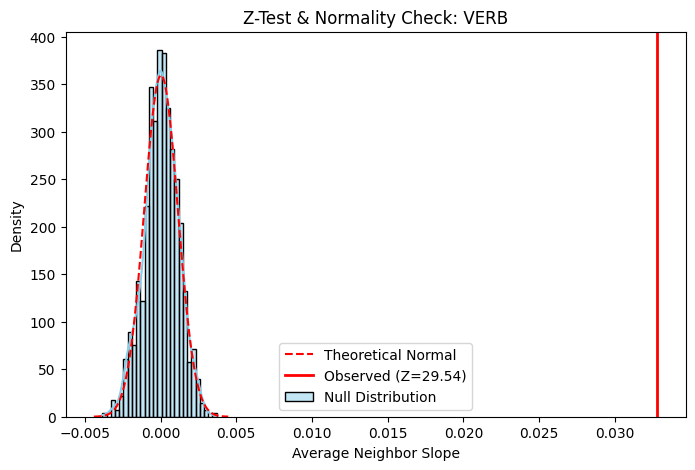

  - Shapiro-Wilk p-value: 0.1523 (Se > 0.05 è una campana perfetta)

VALIDAZIONE PER ADJ:
  - x_bar (Observed): 0.020269
  - mu (Null Mean):   0.000043
  - sigma (Null Std): 0.001683
  - Z-SCORE:          12.0166


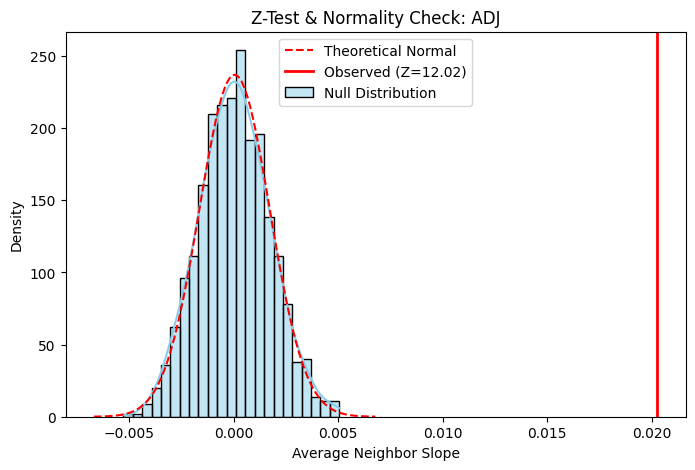

  - Shapiro-Wilk p-value: 0.6678 (Se > 0.05 è una campana perfetta)

VALIDAZIONE PER ADV:
  - x_bar (Observed): 0.020009
  - mu (Null Mean):   -0.000099
  - sigma (Null Std): 0.004984
  - Z-SCORE:          4.0345


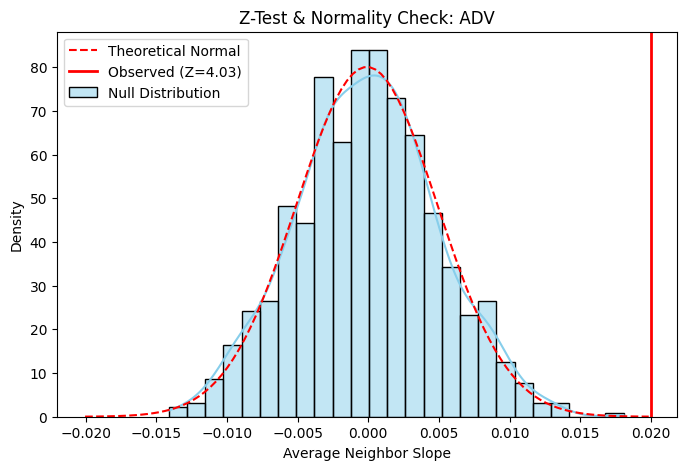

  - Shapiro-Wilk p-value: 0.4843 (Se > 0.05 è una campana perfetta)


In [3]:
import igraph as ig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st # Import corretto per evitare conflitti
from scipy.stats import linregress, norm
from pathlib import Path
import random
import pickle

# =============================================================================
# 1. CONFIGURAZIONE E CARICAMENTO
# =============================================================================
input_dir = Path("networks_paradigmatic")
target_pos = ['NOUN', 'VERB', 'ADJ', 'ADV']
snapshots = range(1, 8)
x_time = np.array(list(snapshots))

def get_avg_neighbor_rel_freq(graph, node_index, total_tokens):
    neighbors = graph.neighbors(node_index)
    if not neighbors: return 0.0
    freqs = [graph.vs[ni]['freq'] for ni in neighbors if graph.vs[ni]['freq'] is not None]
    if not freqs: return 0.0
    return (np.mean(freqs) / total_tokens) * 1_000_000

print("--- 1. Caricamento Grafi e Core Nucleus ---")
graphs = {}
total_tokens_map = {}

for snap in snapshots:
    path = input_dir / f"graph_snap{snap}_paradigmatic.igp"
    g = ig.Graph.Read_Pickle(str(path))
    graphs[snap] = g
    total_tokens_map[snap] = sum([f for f in g.vs['freq'] if f is not None])

core_nodes = set(graphs[1].vs['token'])
for snap in range(2, 8):
    core_nodes = core_nodes.intersection(set(graphs[snap].vs['token']))
core_nodes = list(core_nodes)
pos_map = {v['token']: v['pos'] for v in graphs[1].vs if v['token'] in core_nodes}

# =============================================================================
# 2. CALCOLO SLOPES REALI
# =============================================================================
print("--- 2. Calcolo Pendenze Reali ---")
data = []
y_neigh_history = {}

for name in core_nodes:
    pos = pos_map.get(name, 'UNK')
    if pos not in target_pos: continue
    y_self, y_neigh = [], []
    for snap in snapshots:
        g = graphs[snap]
        idx = g.vs.find(token=name).index
        total = total_tokens_map[snap]
        y_self.append(np.log10(((g.vs[idx]['freq'] / total) * 1_000_000) + 1))
        y_neigh.append(np.log10(get_avg_neighbor_rel_freq(g, idx, total) + 1))
    
    s_self, _, _, _, _ = linregress(x_time, y_self)
    s_neigh, _, _, _, _ = linregress(x_time, y_neigh)
    data.append({'token': name, 'pos': pos, 'slope_self': s_self, 'slope_neigh': s_neigh})
    y_neigh_history[name] = y_neigh

df = pd.DataFrame(data)

# --- SALVATAGGIO DI SICUREZZA ---
df.to_csv("risultati_slopes.csv", index=False)
with open("y_neigh_history.pkl", "wb") as f:
    pickle.dump(y_neigh_history, f)

# =============================================================================
# 3. NULL MODEL 2 CON Z-TEST E CONTROLLO CAMPANA
# =============================================================================

print("\n--- 3. Esecuzione Null Model & Validazione (Z-Test) ---")
n_iterations = 1000

for pos in target_pos:
    # Identifichiamo i Winners (Top 25% crescita)
    subset = df[df['pos'] == pos]
    threshold = subset['slope_self'].quantile(0.75)
    winners = subset[subset['slope_self'] >= threshold]
    
    # PARAMETRO x_bar (Osservato reale)
    x_bar = winners['slope_neigh'].mean()
    
    # Generazione Distribuzione Nulla (Temporal Shuffle)
    null_means = []
    for _ in range(n_iterations):
        shuffled_slopes = []
        for token in winners['token']:
            y_val = list(y_neigh_history[token])
            random.shuffle(y_val) 
            s_rand, _, _, _, _ = linregress(x_time, y_val)
            shuffled_slopes.append(s_rand)
        null_means.append(np.mean(shuffled_slopes))
    
    null_means = np.array(null_means)
    
    # PARAMETRI mu e sigma (Dalla distribuzione nulla)
    mu_null = np.mean(null_means)
    sigma_null = np.std(null_means) # Questo è tecnicamente lo Standard Error
    
    # CALCOLO Z-TEST (Formula: (x_bar - mu) / sigma)
    z_score = (x_bar - mu_null) / sigma_null
    
    print(f"\nVALIDAZIONE PER {pos}:")
    print(f"  - x_bar (Observed): {x_bar:.6f}")
    print(f"  - mu (Null Mean):   {mu_null:.6f}")
    print(f"  - sigma (Null Std): {sigma_null:.6f}")
    print(f"  - Z-SCORE:          {z_score:.4f}")

    # --- PLOT DELLA CAMPANA ---
    plt.figure(figsize=(8, 5))
    sns.histplot(null_means, kde=True, color="skyblue", stat="density", label="Null Distribution")
    
    # Curva normale teorica basata sui parametri nulli
    x_range = np.linspace(mu_null - 4*sigma_null, mu_null + 4*sigma_null, 100)
    plt.plot(x_range, norm.pdf(x_range, mu_null, sigma_null), color="red", linestyle="--", label="Theoretical Normal")
    
    # Linea del valore reale osservato (Se è lontano, lo Z è alto)
    plt.axvline(x_bar, color="red", lw=2, label=f"Observed (Z={z_score:.2f})")
    
    plt.title(f"Z-Test & Normality Check: {pos}")
    plt.xlabel("Average Neighbor Slope")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    # Test di normalità di Shapiro-Wilk (Corretto)
    
    _, p_norm = st.shapiro(null_means)
    print(f"  - Shapiro-Wilk p-value: {p_norm:.4f} (Se > 0.05 è una campana perfetta)")